# KU-HAR — Human Activity Recognition con Deep Learning

Notebook modular para:

- descarga automática desde Kaggle;
- validación de los 6 canales × 300 pasos temporales;
- análisis exploratorio;
- preprocesamiento robusto sin fuga de información;
- experimentos independientes con **CNN 1D**, **BiLSTM** y **CRNN**;
- evaluación y guardado automático de resultados.

> Cada celda comienza con un índice para facilitar el seguimiento y la depuración.

## 1. Configuración del entorno

In [1]:
# 1.2 — IMPORTACIÓN DE LIBRERÍAS

import os
import sys
import json
import time
import random
import shutil
import platform
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import lightning as L
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint, LearningRateMonitor
from lightning.pytorch.loggers import CSVLogger

from torchmetrics.classification import MulticlassAccuracy, MulticlassF1Score

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore")

print("Python     :", platform.python_version())
print("PyTorch   :", torch.__version__)
print("Lightning :", L.__version__)

Python     : 3.11.12
PyTorch   : 2.11.0+cu128
Lightning : 2.6.5


In [2]:
# 1.3 — REPRODUCIBILIDAD

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
L.seed_everything(SEED, workers=True)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Semilla configurada:", SEED)

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


Semilla configurada: 42


In [3]:
# 1.4 — DETECCIÓN SEGURA DEL HARDWARE

def detect_device():
    if not torch.cuda.is_available():
        return torch.device("cpu"), None

    try:
        test_tensor = torch.tensor([1.0], device="cuda")
        _ = test_tensor * 2
        torch.cuda.synchronize()
        gpu_name = torch.cuda.get_device_name(0)
        del test_tensor
        torch.cuda.empty_cache()
        return torch.device("cuda"), gpu_name
    except Exception as error:
        print("CUDA detectada, pero no pudo inicializarse:")
        print(error)
        return torch.device("cpu"), None

DEVICE, GPU_NAME = detect_device()
USE_GPU = DEVICE.type == "cuda"

ACCELERATOR = "gpu" if USE_GPU else "cpu"
DEVICES = 1
TRAINING_PRECISION = "16-mixed" if USE_GPU else "32-true"
PIN_MEMORY = USE_GPU
NUM_WORKERS = 2 if USE_GPU else 0

if USE_GPU:
    torch.set_float32_matmul_precision("high")
    torch.backends.cudnn.benchmark = True

print("Dispositivo :", DEVICE)
print("GPU         :", GPU_NAME)
print("Precisión   :", TRAINING_PRECISION)

Dispositivo : cpu
GPU         : None
Precisión   : 32-true


In [4]:
# 1.5 — CONSTANTES DEL DATASET

NUM_CLASSES = 18
NUM_CHANNELS = 6
SEQUENCE_LENGTH = 300
NUM_FEATURES = NUM_CHANNELS * SEQUENCE_LENGTH
EXPECTED_TOTAL_COLUMNS = NUM_FEATURES + 3

CHANNEL_NAMES = [
    "Acc X", "Acc Y", "Acc Z",
    "Gyro X", "Gyro Y", "Gyro Z"
]

ACTIVITY_NAMES = {
    0: "Stand",
    1: "Sit",
    2: "Talk-Sit",
    3: "Talk-Stand",
    4: "Stand-Sit",
    5: "Lay",
    6: "Lay-Stand",
    7: "Pick",
    8: "Jump",
    9: "Push-up",
    10: "Sit-up",
    11: "Walk",
    12: "Walk-Backward",
    13: "Walk-Circle",
    14: "Run",
    15: "Stair-Up",
    16: "Stair-Down",
    17: "Table-Tennis"
}

assert len(ACTIVITY_NAMES) == NUM_CLASSES

print("Clases       :", NUM_CLASSES)
print("Canales      :", NUM_CHANNELS)
print("Pasos        :", SEQUENCE_LENGTH)
print("Características:", NUM_FEATURES)

Clases       : 18
Canales      : 6
Pasos        : 300
Características: 1800


In [5]:
# 1.6 — RUTAS DE RESULTADOS

PROJECT_ROOT = Path("/content") if Path("/content").exists() else Path.cwd()
RESULTS_ROOT = PROJECT_ROOT / "kuhar_results"
EDA_RESULTS_ROOT = RESULTS_ROOT / "EDA"
MODELS_RESULTS_ROOT = RESULTS_ROOT / "Models"
SUMMARY_RESULTS_ROOT = RESULTS_ROOT / "Summary"

for directory in [RESULTS_ROOT, EDA_RESULTS_ROOT, MODELS_RESULTS_ROOT, SUMMARY_RESULTS_ROOT]:
    directory.mkdir(parents=True, exist_ok=True)

print("Resultados:", RESULTS_ROOT)

Resultados: /content/kuhar_results


In [6]:
# 2.1 — DESCARGA AUTOMÁTICA DESDE KAGGLE

import kagglehub

KAGGLE_DATASET_ID = "niloy333/kuhar"

download_path = kagglehub.dataset_download(KAGGLE_DATASET_ID)
KAGGLE_ROOT = Path(download_path)

print("Dataset descargado en:")
print(KAGGLE_ROOT)

Dataset descargado en:
/root/.cache/kagglehub/datasets/niloy333/kuhar/versions/1


In [7]:
# 2.2 — LOCALIZACIÓN DEL CSV CONSOLIDADO

TARGET_FILENAME = "KU-HAR_time_domain_subsamples_20750x300.csv"

dataset_candidates = list(KAGGLE_ROOT.rglob(TARGET_FILENAME))
description_candidates = list(KAGGLE_ROOT.rglob("description.txt"))

if len(dataset_candidates) != 1:
    raise RuntimeError(
        f"Se esperaba exactamente un archivo {TARGET_FILENAME}, "
        f"pero se encontraron {len(dataset_candidates)}."
    )

DATASET_PATH = dataset_candidates[0]
DESCRIPTION_PATH = description_candidates[0] if description_candidates else None

print("CSV        :", DATASET_PATH)
print("Descripción:", DESCRIPTION_PATH)

CSV        : /root/.cache/kagglehub/datasets/niloy333/kuhar/versions/1/3.Time_domain_subsamples/KU-HAR_time_domain_subsamples_20750x300.csv
Descripción: /root/.cache/kagglehub/datasets/niloy333/kuhar/versions/1/description.txt


In [8]:
# 2.3 — LECTURA DE LA DESCRIPCIÓN

if DESCRIPTION_PATH is not None:
    print(DESCRIPTION_PATH.read_text(encoding="utf-8", errors="replace"))
else:
    print("No se encontró description.txt.")

(Please use this version of the dataset)

Human Activity Recognition (HAR) refers to the capacity of machines to perceive human actions. This dataset contains information on 18 different activities collected from 90 participants (75 male and 15 female) using smartphone sensors (Accelerometer and Gyroscope). It has 1945 raw activity samples collected directly from the participants, and 20750 subsamples extracted from them. The activities are:

Stand➞ Standing still (1 min)
Sit➞ Sitting still (1 min) 
Talk-sit➞ Talking with hand movements while sitting (1 min) 
Talk-stand➞ Talking with hand movements while standing or walking(1 min) 
Stand-sit➞ Repeatedly standing up and sitting down (5 times)
Lay➞ Laying still (1 min) 
Lay-stand➞ Repeatedly standing up and laying down (5 times)
Pick➞ Picking up an object from the floor (10 times)
Jump➞ Jumping repeatedly (10 times)
Push-up➞ Performing full push-ups (5 times)
Sit-up➞ Performing sit-ups (5 times)
Walk➞ Walking 20 meters (≈12 s)
Walk-backw

In [9]:
# 2.4 — CARGA COMPLETA DEL CSV

har_df_raw = pd.read_csv(DATASET_PATH, header=None)

print("Dimensiones:", har_df_raw.shape)

assert har_df_raw.shape == (20750, EXPECTED_TOTAL_COLUMNS), (
    f"Se esperaba (20750, {EXPECTED_TOTAL_COLUMNS}), "
    f"pero se obtuvo {har_df_raw.shape}."
)

display(har_df_raw.iloc[:5, :8])

Dimensiones: (20750, 1803)


,0,1,2,3,4,5,6,7
0,0.004230,-0.000280,-0.013906,-0.002544,0.027433,0.058300,0.051670,0.071857
1,0.012482,0.032496,0.067856,0.071552,0.078103,0.040353,-0.001059,-0.018580
2,0.012127,0.028458,0.062075,0.052611,0.022942,-0.010017,-0.023151,-0.028515
3,0.052964,0.074319,0.110670,0.108490,0.091825,0.056989,0.029337,-0.016724
4,-0.020462,-0.030787,-0.008617,0.008906,0.045046,0.042136,0.045037,0.045182


In [10]:
# 2.5 — ASIGNACIÓN DE NOMBRES DE COLUMNAS

feature_columns = []

for prefix in ["acc_x", "acc_y", "acc_z", "gyro_x", "gyro_y", "gyro_z"]:
    feature_columns.extend([f"{prefix}_{step}" for step in range(SEQUENCE_LENGTH)])

metadata_columns = ["activity", "window_length", "sample_id"]
all_columns = feature_columns + metadata_columns

har_df = har_df_raw.copy()
har_df.columns = all_columns

har_df[feature_columns] = har_df[feature_columns].astype(np.float32)
har_df["activity"] = har_df["activity"].astype(np.int64)
har_df["window_length"] = har_df["window_length"].astype(np.int64)
har_df["sample_id"] = har_df["sample_id"].astype(np.int64)

print("Columnas de características:", len(feature_columns))
print("Columnas totales           :", len(all_columns))

Columnas de características: 1800
Columnas totales           : 1803


In [11]:
# 2.6 — COPIAS BASE QUE NO SE SOBRESCRIBIRÁN

X_clean = har_df[feature_columns].to_numpy(dtype=np.float32, copy=True)
y_clean = har_df["activity"].to_numpy(dtype=np.int64, copy=True)
sample_ids_clean = har_df["sample_id"].to_numpy(dtype=np.int64, copy=True)

X_matrix_clean = X_clean.reshape(-1, NUM_CHANNELS, SEQUENCE_LENGTH)

print("X plano   :", X_clean.shape)
print("X matricial:", X_matrix_clean.shape)
print("y         :", y_clean.shape)

assert X_matrix_clean.shape == (20750, 6, 300)

X plano   : (20750, 1800)
X matricial: (20750, 6, 300)
y         : (20750,)


In [12]:
# 3.1 — VALIDACIÓN DE INTEGRIDAD

assert np.isnan(X_clean).sum() == 0
assert np.isinf(X_clean).sum() == 0
assert X_clean.dtype == np.float32
assert y_clean.dtype == np.int64
assert sorted(np.unique(y_clean).tolist()) == list(range(NUM_CLASSES))
assert np.unique(har_df["window_length"]).tolist() == [SEQUENCE_LENGTH]
assert len(np.unique(sample_ids_clean)) == len(sample_ids_clean)

print("Integridad básica verificada.")

Integridad básica verificada.


In [13]:
# 3.2 — DISTRIBUCIÓN DE CLASES

class_counts = np.bincount(y_clean, minlength=NUM_CLASSES)

class_distribution_df = pd.DataFrame({
    "activity_id": np.arange(NUM_CLASSES),
    "activity": [ACTIVITY_NAMES[i] for i in range(NUM_CLASSES)],
    "samples": class_counts
})

class_distribution_df["percentage"] = (
    class_distribution_df["samples"] / len(y_clean) * 100
)

display(class_distribution_df)

imbalance_ratio = class_counts.max() / class_counts.min()
print("Relación de desbalance:", round(float(imbalance_ratio), 2))

,activity_id,activity,samples,percentage
0,0,Stand,1886,9.089157
1,1,Sit,1874,9.031325
2,2,Talk-Sit,1797,8.660241
3,3,Talk-Stand,1866,8.992771
4,4,Stand-Sit,2178,10.496386
5,5,Lay,1813,8.737349
6,6,Lay-Stand,1762,8.491566
7,7,Pick,1333,6.424096
8,8,Jump,666,3.209639
9,9,Push-up,480,2.313253


Relación de desbalance: 8.41


In [14]:
# 3.3 — VERIFICACIÓN EXACTA DEL RESHAPE

rng = np.random.default_rng(SEED)
audit_positions = rng.choice(len(X_clean), size=20, replace=False)

for position in audit_positions:
    flat = X_clean[position]
    matrix = X_matrix_clean[position]
    reconstructed = matrix.reshape(-1)

    assert np.array_equal(flat, reconstructed)
    assert np.array_equal(matrix[0], flat[0:300])
    assert np.array_equal(matrix[1], flat[300:600])
    assert np.array_equal(matrix[2], flat[600:900])
    assert np.array_equal(matrix[3], flat[900:1200])
    assert np.array_equal(matrix[4], flat[1200:1500])
    assert np.array_equal(matrix[5], flat[1500:1800])

print("Reshape y orden de canales verificados en 20 muestras aleatorias.")

Reshape y orden de canales verificados en 20 muestras aleatorias.


In [15]:
# 3.4 — AUDITORÍA DE VALORES EXTREMOS SIN ELIMINAR DATOS

sample_abs_max = np.abs(X_matrix_clean).max(axis=(1, 2))

extreme_audit_df = pd.DataFrame({
    "dataset_position": np.arange(len(X_clean)),
    "sample_id": sample_ids_clean,
    "activity_id": y_clean,
    "activity": [ACTIVITY_NAMES[int(i)] for i in y_clean],
    "absolute_maximum": sample_abs_max
}).sort_values("absolute_maximum", ascending=False)

display(extreme_audit_df.head(20))

print("Nota: esta tabla es solo diagnóstica. No se eliminarán muestras automáticamente.")

,dataset_position,sample_id,activity_id,activity,absolute_maximum
6600,6600,6601,14,Run,189630.0
6601,6601,6602,14,Run,189630.0
6599,6599,6600,14,Run,187000.0
6602,6602,6603,14,Run,186430.0
6762,6762,6763,14,Run,183940.0
6763,6763,6764,14,Run,183940.0
6598,6598,6599,14,Run,179390.0
6761,6761,6762,14,Run,178770.0
6764,6764,6765,14,Run,177240.0
6603,6603,6604,14,Run,176590.0


Nota: esta tabla es solo diagnóstica. No se eliminarán muestras automáticamente.


In [16]:
# 3.5 — RESUMEN DE VALIDACIÓN

validation_summary = {
    "samples": int(len(X_clean)),
    "features_per_sample": int(X_clean.shape[1]),
    "channels": NUM_CHANNELS,
    "time_steps": SEQUENCE_LENGTH,
    "classes": NUM_CLASSES,
    "missing_values": int(np.isnan(X_clean).sum()),
    "infinite_values": int(np.isinf(X_clean).sum()),
    "unique_sample_ids": int(len(np.unique(sample_ids_clean))),
    "imbalance_ratio": float(imbalance_ratio),
    "global_absolute_maximum": float(np.abs(X_clean).max())
}

print(json.dumps(validation_summary, indent=4))

{
    "samples": 20750,
    "features_per_sample": 1800,
    "channels": 6,
    "time_steps": 300,
    "classes": 18,
    "missing_values": 0,
    "infinite_values": 0,
    "unique_sample_ids": 20750,
    "imbalance_ratio": 8.40926640926641,
    "global_absolute_maximum": 189630.0
}



## 4. Análisis exploratorio - EDA


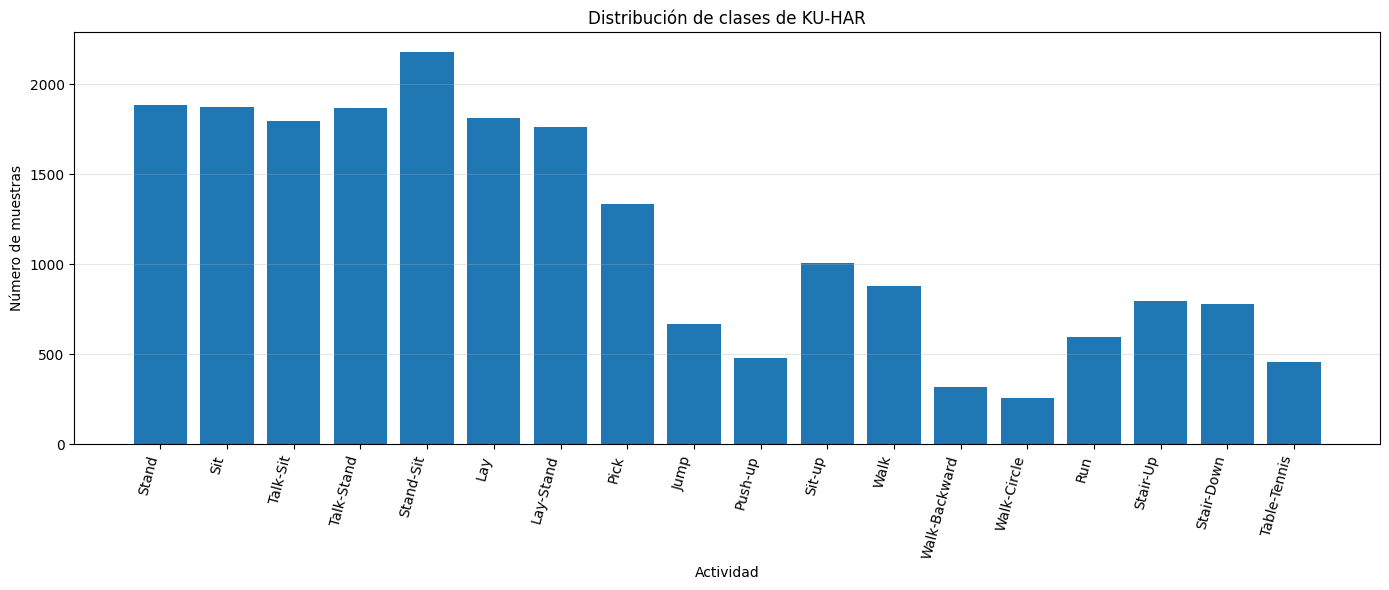

Guardado: /content/kuhar_results/EDA/class_distribution.png


In [18]:
# 4.1 — DISTRIBUCIÓN VISUAL DE CLASES

plt.figure(figsize=(14, 6))
plt.bar(class_distribution_df["activity"], class_distribution_df["samples"])
plt.xlabel("Actividad")
plt.ylabel("Número de muestras")
plt.title("Distribución de clases de KU-HAR")
plt.xticks(rotation=75, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

path = EDA_RESULTS_ROOT / "class_distribution.png"
plt.savefig(path, dpi=300, bbox_inches="tight")
plt.show()

print("Guardado:", path)

In [19]:
# 4.2 — FUNCIONES DE VISUALIZACIÓN DE SEÑALES

def sensor_magnitude(x, y, z):
    return np.sqrt(x**2 + y**2 + z**2)

def get_activity_sample(activity_id, sample_number=0):
    positions = np.where(y_clean == activity_id)[0]

    if activity_id not in ACTIVITY_NAMES:
        raise ValueError("activity_id debe estar entre 0 y 17.")

    if not 0 <= sample_number < len(positions):
        raise IndexError("sample_number fuera de rango.")

    dataset_position = int(positions[sample_number])
    return dataset_position, X_matrix_clean[dataset_position]

def plot_complete_activity_sample(activity_id, sample_number=0, save=True):
    position, signal = get_activity_sample(activity_id, sample_number)

    acc_mag = sensor_magnitude(signal[0], signal[1], signal[2])
    gyro_mag = sensor_magnitude(signal[3], signal[4], signal[5])
    time_steps = np.arange(SEQUENCE_LENGTH)
    activity_name = ACTIVITY_NAMES[activity_id]

    fig, axes = plt.subplots(4, 1, figsize=(15, 14), sharex=True)

    for values, label in zip(signal[:3], ["Acc X", "Acc Y", "Acc Z"]):
        axes[0].plot(time_steps, values, label=label)
    axes[0].set_title(f"Acelerómetro — {activity_name}")
    axes[0].set_ylabel("m/s²")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    for values, label in zip(signal[3:], ["Gyro X", "Gyro Y", "Gyro Z"]):
        axes[1].plot(time_steps, values, label=label)
    axes[1].set_title(f"Giroscopio — {activity_name}")
    axes[1].set_ylabel("rad/s")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    axes[2].plot(time_steps, acc_mag)
    axes[2].set_title("Magnitud del acelerómetro")
    axes[2].set_ylabel("m/s²")
    axes[2].grid(alpha=0.3)

    axes[3].plot(time_steps, gyro_mag)
    axes[3].set_title("Magnitud del giroscopio")
    axes[3].set_ylabel("rad/s")
    axes[3].set_xlabel("Paso temporal")
    axes[3].grid(alpha=0.3)

    fig.suptitle(
        f"Muestra de 3 segundos | Actividad: {activity_name} | "
        f"Sample ID: {sample_ids_clean[position]}",
        fontsize=15
    )

    plt.tight_layout(rect=[0, 0, 1, 0.96])

    if save:
        safe_name = activity_name.lower().replace("-", "_").replace(" ", "_")
        figure_path = EDA_RESULTS_ROOT / f"sample_{safe_name}.png"
        fig.savefig(figure_path, dpi=300, bbox_inches="tight")
        print("Guardado:", figure_path)

    return fig

Guardado: /content/kuhar_results/EDA/sample_stand.png


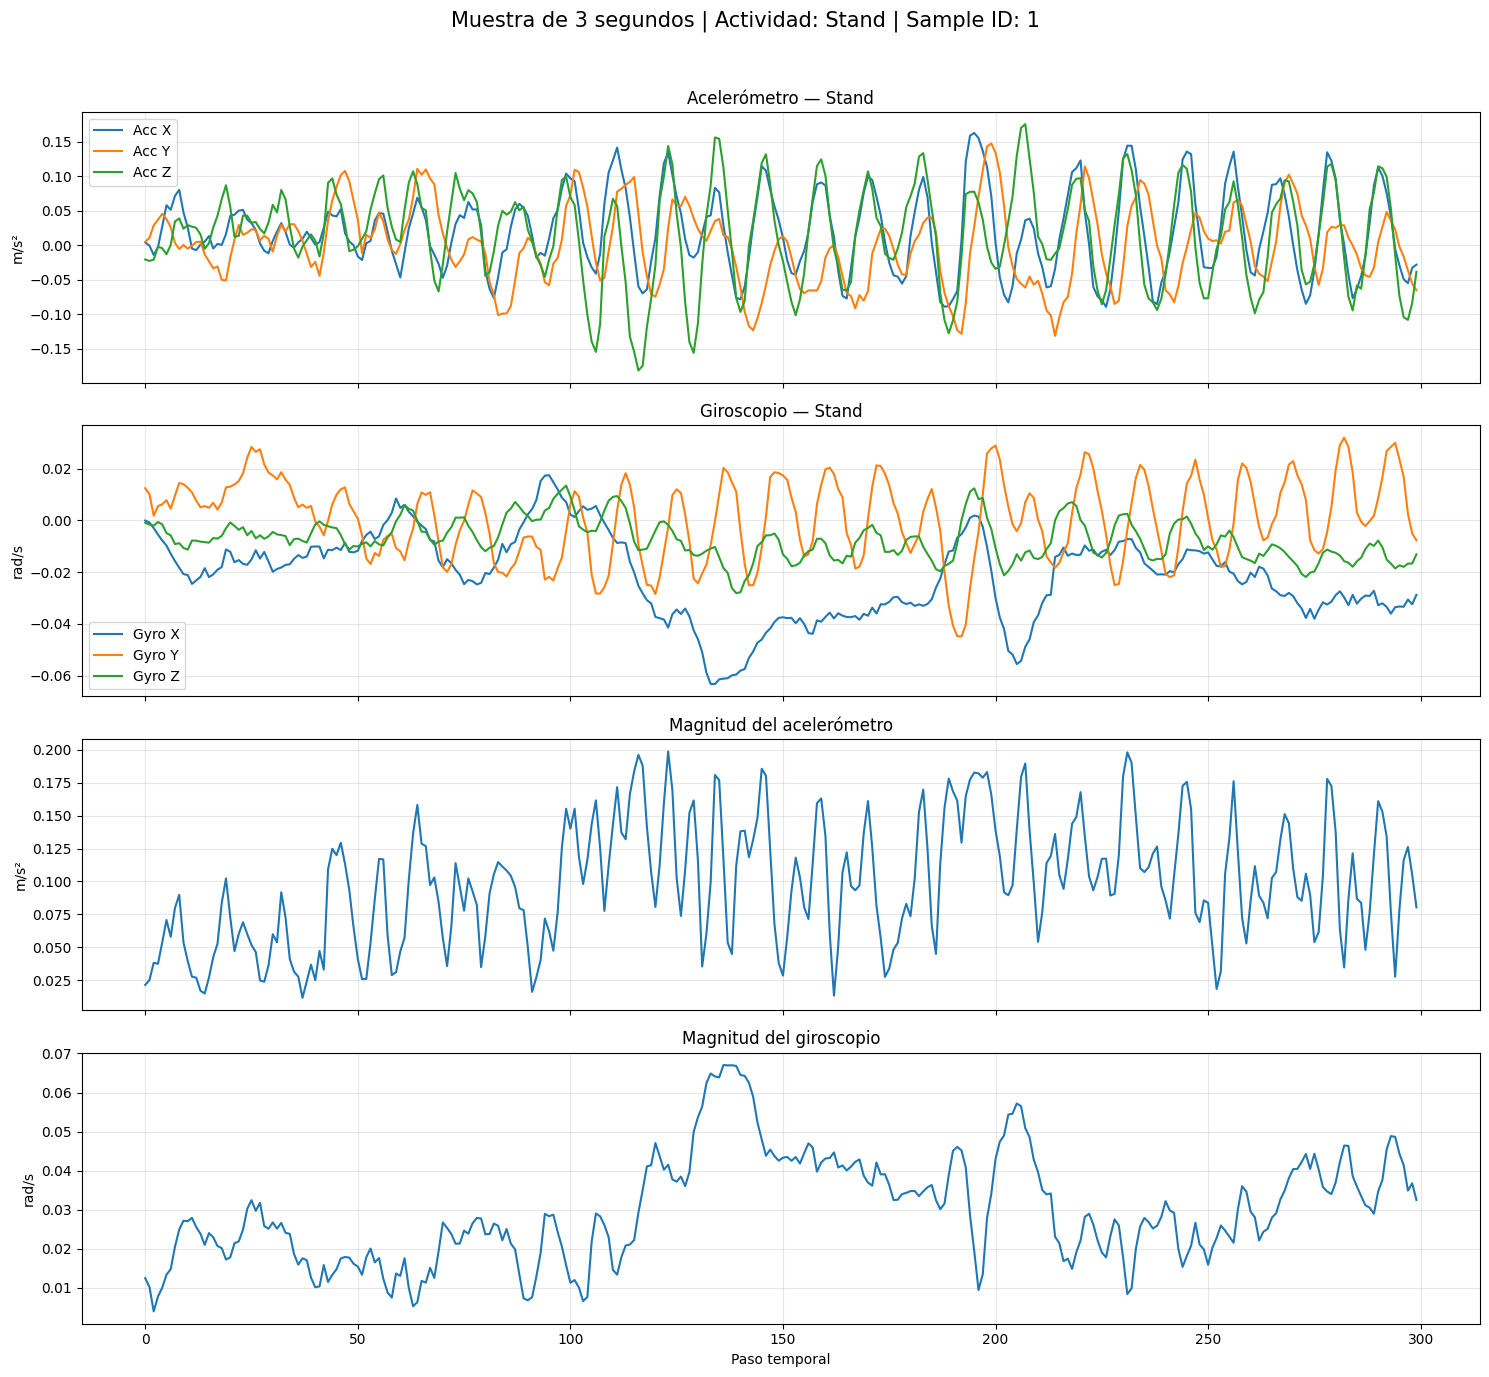

Guardado: /content/kuhar_results/EDA/sample_walk.png


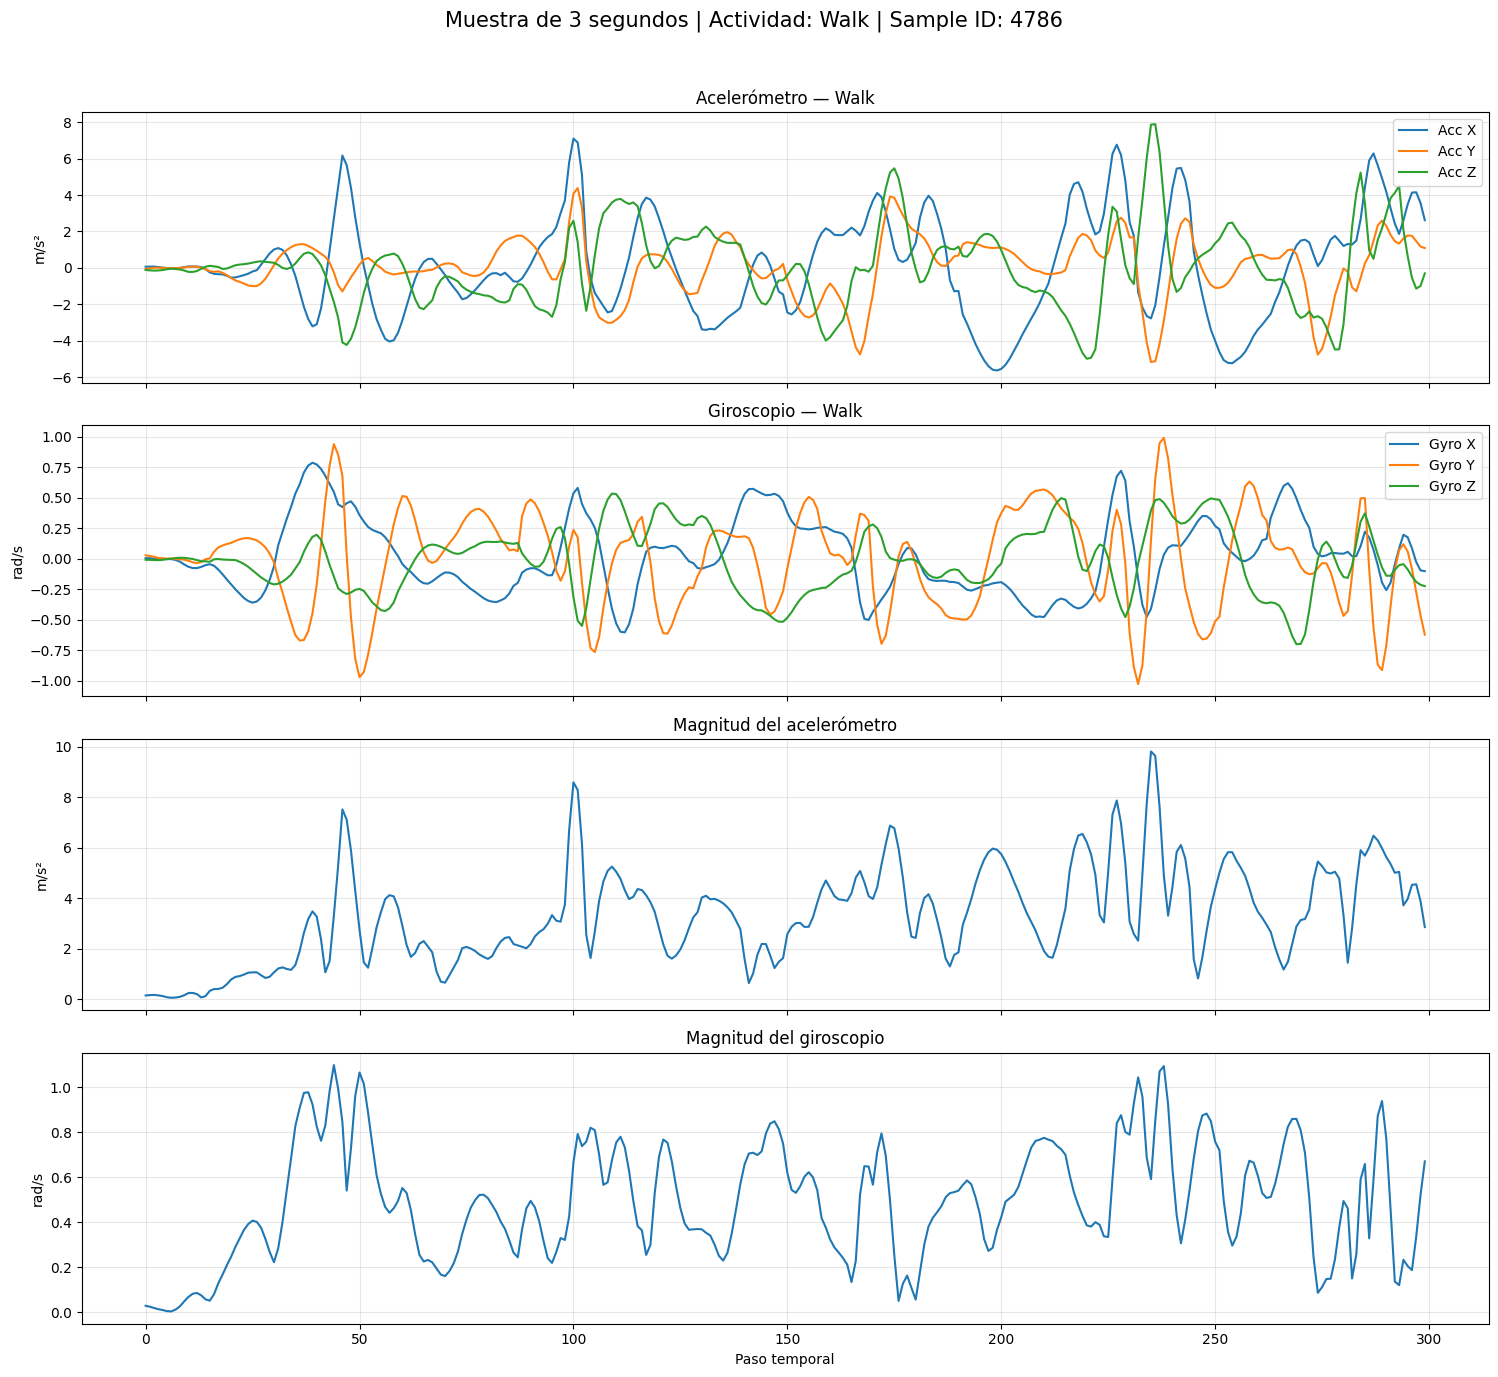

Guardado: /content/kuhar_results/EDA/sample_run.png


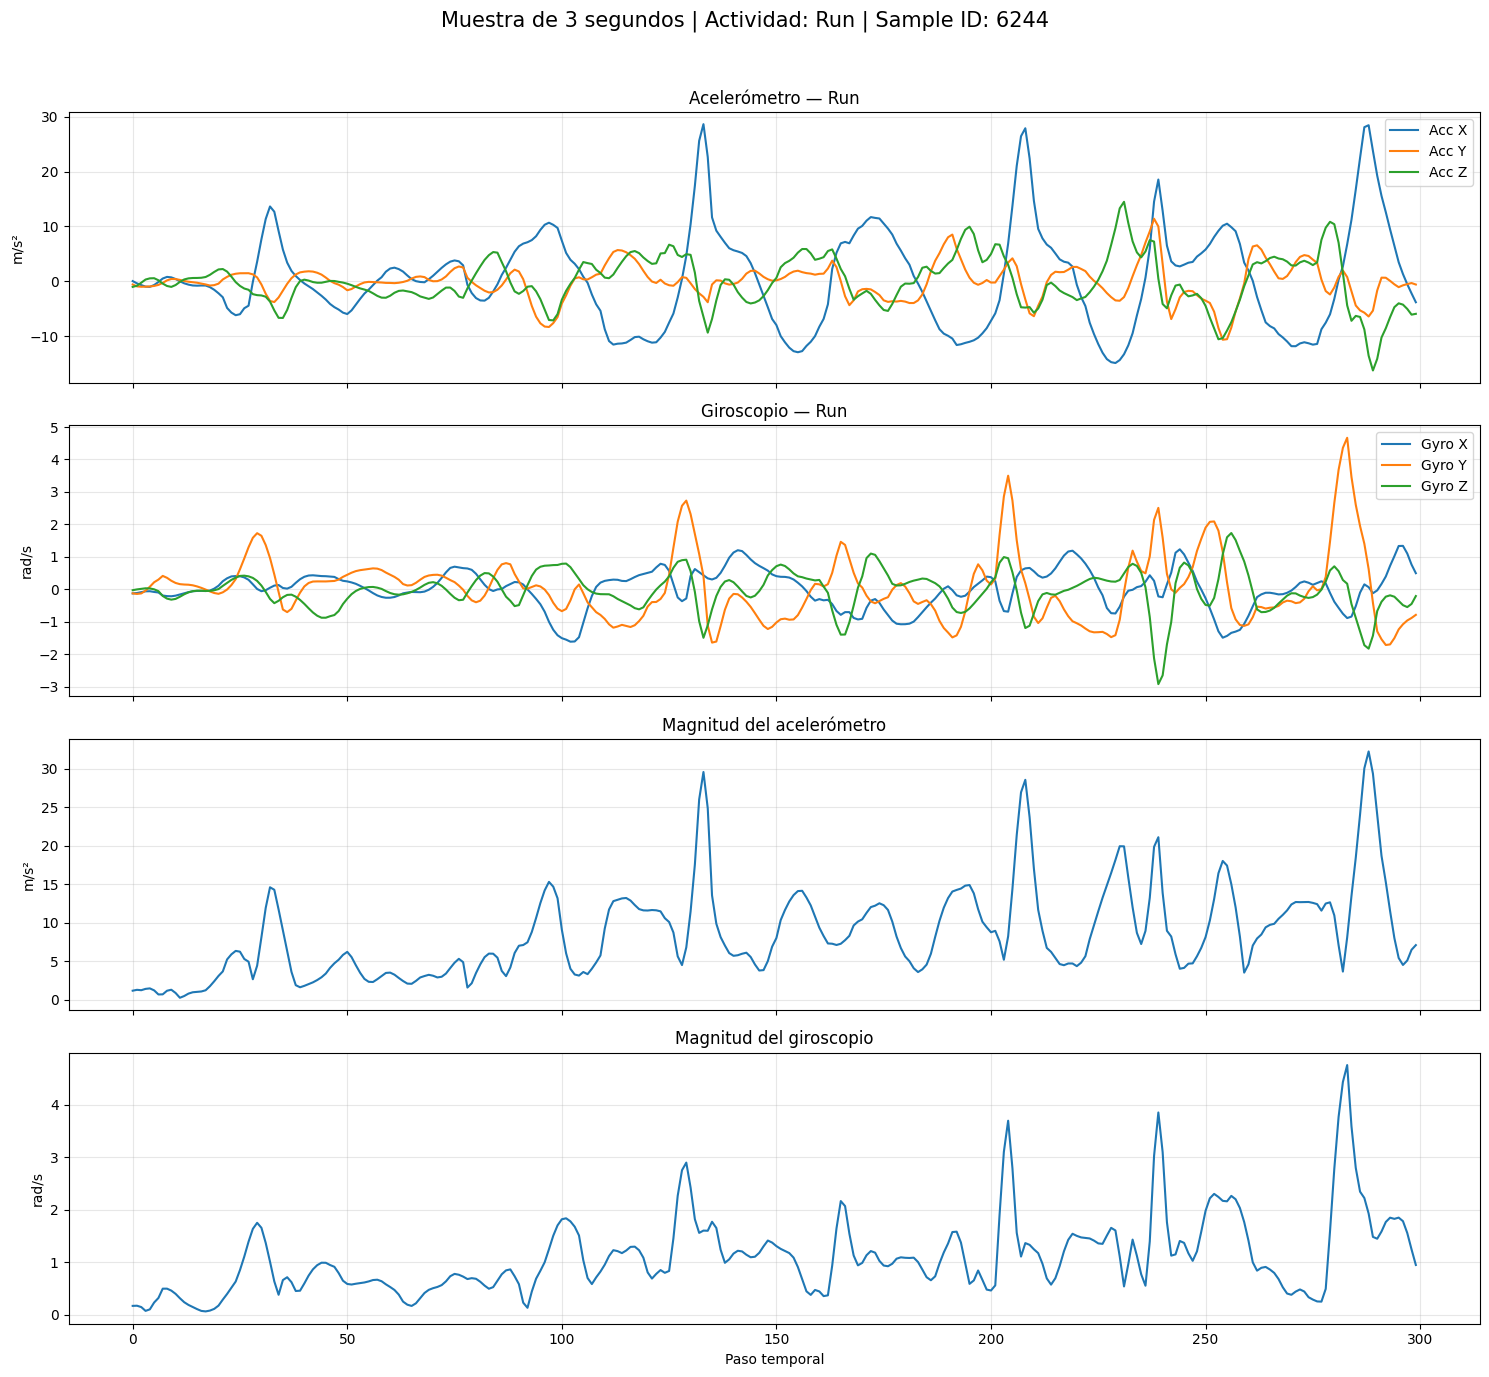

Guardado: /content/kuhar_results/EDA/sample_jump.png


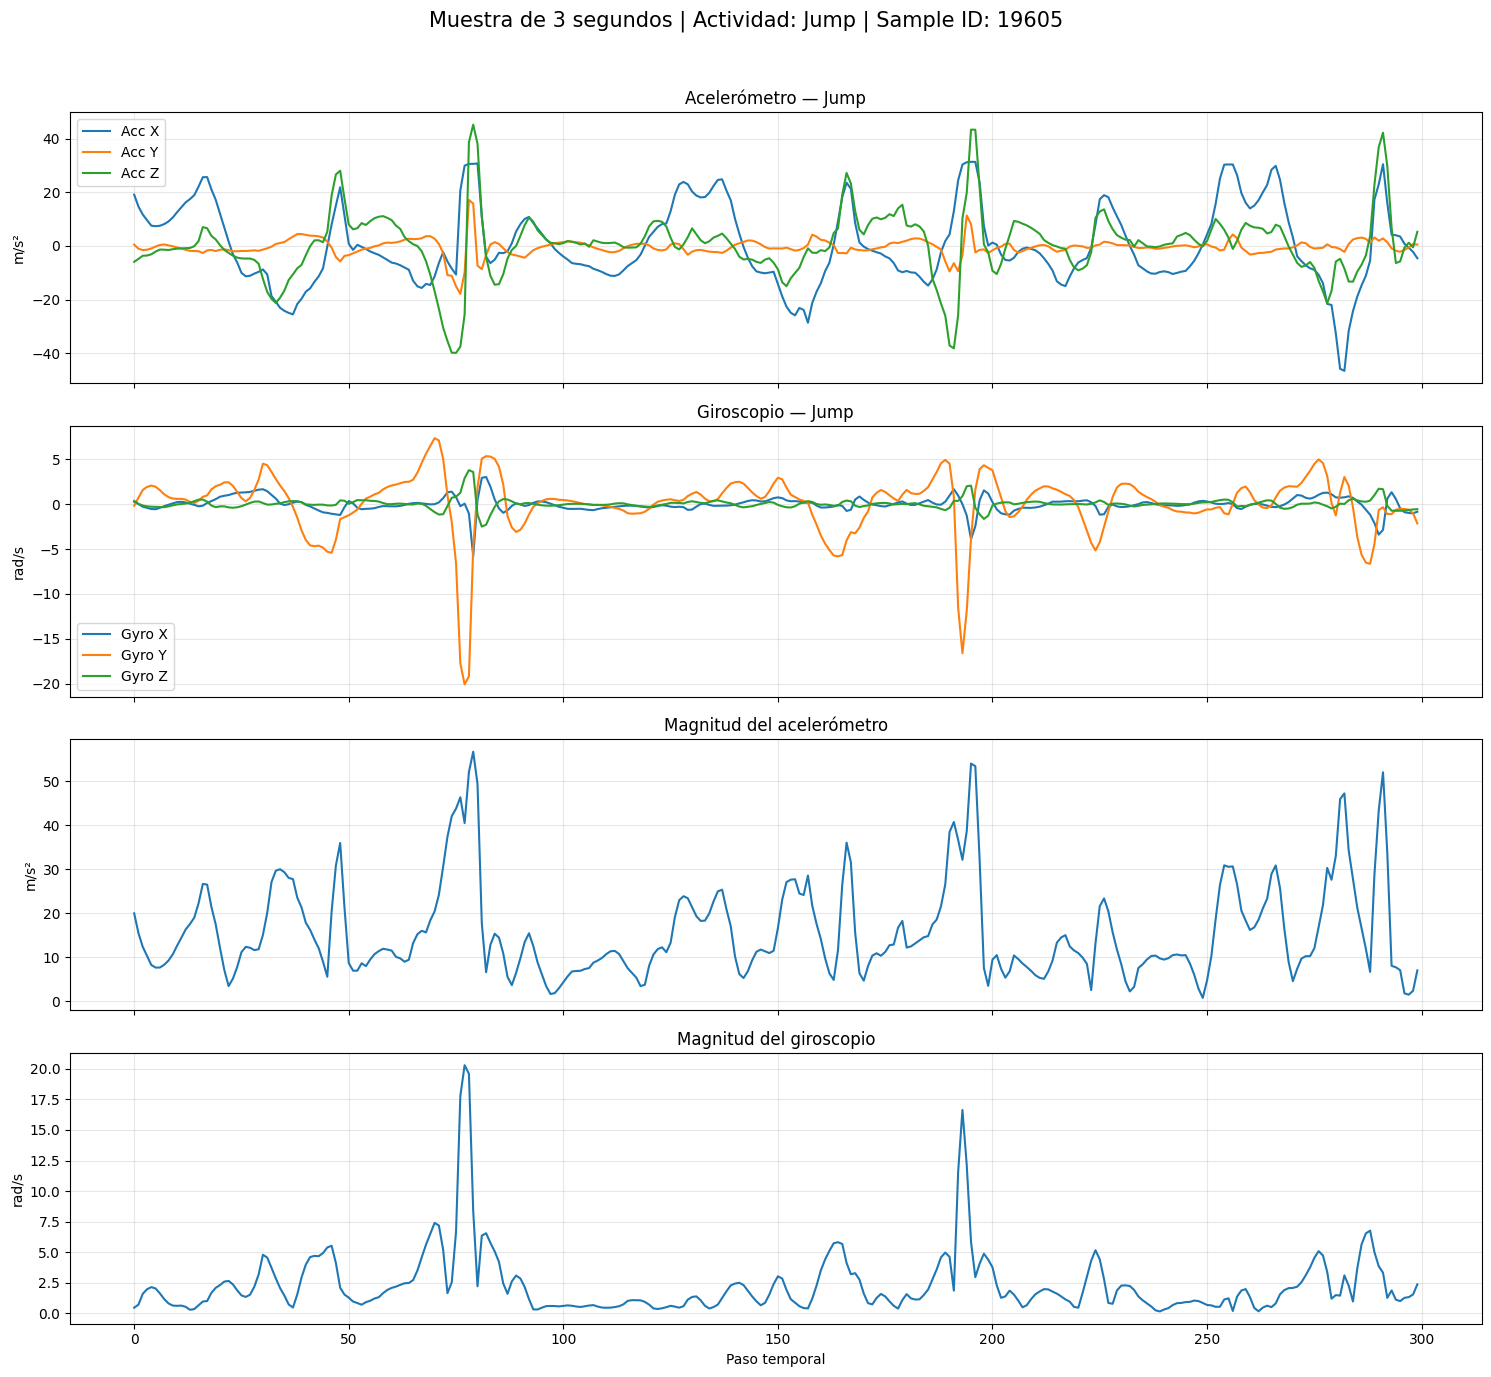

In [20]:
# 4.3 — EJEMPLOS REPRESENTATIVOS

for activity_id in [0, 11, 14, 8]:
    plot_complete_activity_sample(activity_id, sample_number=0, save=True)
    plt.show()

In [21]:
# 4.4 — MAGNITUD MEDIANA POR ACTIVIDAD

magnitude_records = []

for position, signal in enumerate(X_matrix_clean):
    acc_mag = sensor_magnitude(signal[0], signal[1], signal[2])
    gyro_mag = sensor_magnitude(signal[3], signal[4], signal[5])

    magnitude_records.append({
        "activity_id": int(y_clean[position]),
        "activity": ACTIVITY_NAMES[int(y_clean[position])],
        "mean_acc_magnitude": float(acc_mag.mean()),
        "mean_gyro_magnitude": float(gyro_mag.mean())
    })

magnitude_df = pd.DataFrame(magnitude_records)

magnitude_summary = (
    magnitude_df
    .groupby(["activity_id", "activity"], as_index=False)
    .agg(
        median_acc_magnitude=("mean_acc_magnitude", "median"),
        median_gyro_magnitude=("mean_gyro_magnitude", "median")
    )
    .sort_values("activity_id")
)

display(magnitude_summary)

,activity_id,activity,median_acc_magnitude,median_gyro_magnitude
0,0,Stand,0.049693,0.012972
1,1,Sit,0.037938,0.010234
2,2,Talk-Sit,0.143283,0.040852
3,3,Talk-Stand,1.275798,0.733885
4,4,Stand-Sit,1.239711,0.663780
5,5,Lay,0.053611,0.018406
6,6,Lay-Stand,1.162396,0.886984
7,7,Pick,1.829598,0.734081
8,8,Jump,10.256623,1.500637
9,9,Push-up,2.586208,0.644342


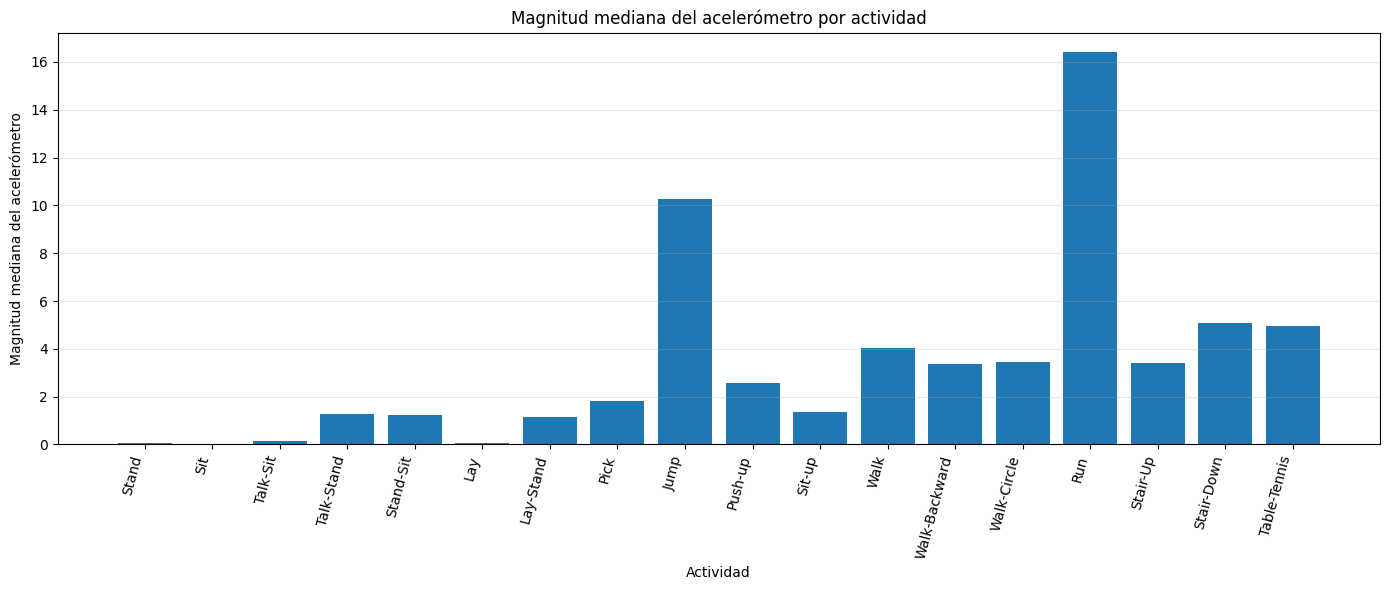

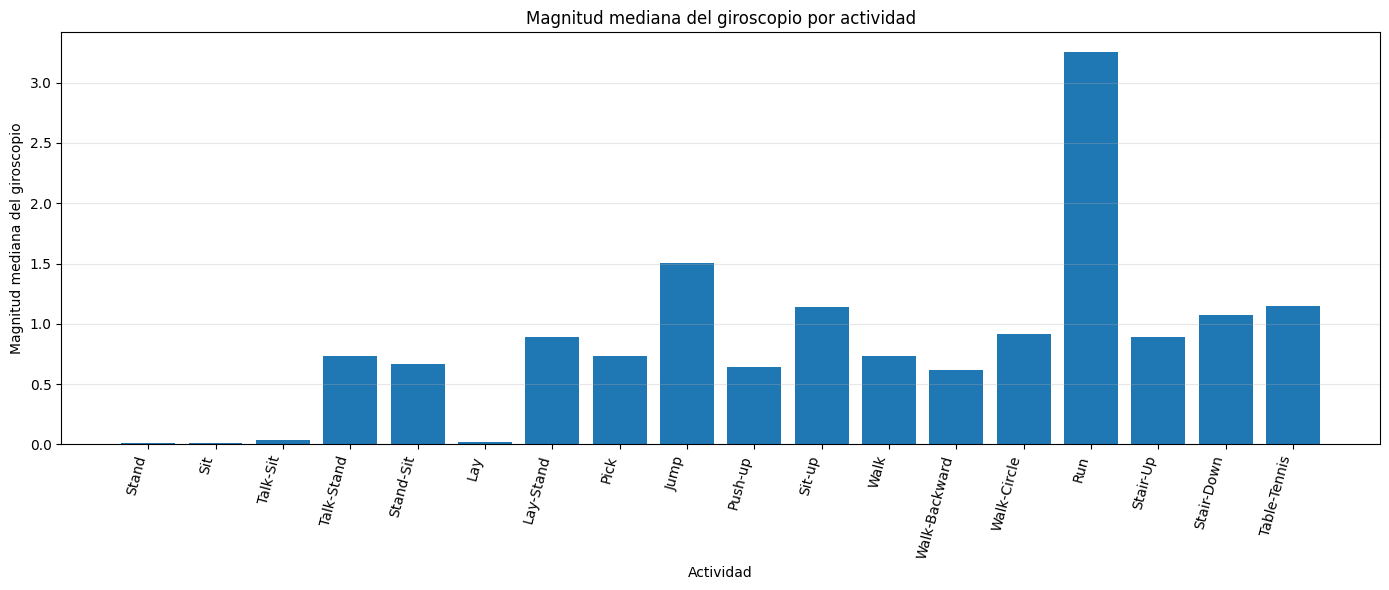

In [22]:
# 4.5 — GRÁFICOS DE MAGNITUD MEDIANA

plt.figure(figsize=(14, 6))
plt.bar(magnitude_summary["activity"], magnitude_summary["median_acc_magnitude"])
plt.xlabel("Actividad")
plt.ylabel("Magnitud mediana del acelerómetro")
plt.title("Magnitud mediana del acelerómetro por actividad")
plt.xticks(rotation=75, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(EDA_RESULTS_ROOT / "median_acc_magnitude.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(14, 6))
plt.bar(magnitude_summary["activity"], magnitude_summary["median_gyro_magnitude"])
plt.xlabel("Actividad")
plt.ylabel("Magnitud mediana del giroscopio")
plt.title("Magnitud mediana del giroscopio por actividad")
plt.xticks(rotation=75, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(EDA_RESULTS_ROOT / "median_gyro_magnitude.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. Preprocesamiento

Se utilizará una estrategia robusta:

1. división estratificada mediante índices;
2. cálculo de mediana e IQR exclusivamente con entrenamiento;
3. escalado por canal;
4. recorte de valores estandarizados a `[-10, 10]`.

El recorte evita que unos pocos registros extremos dominen la optimización, sin eliminar clases ni muestras completas.

In [23]:
# 5.1 — DIVISIÓN ESTRATIFICADA MEDIANTE ÍNDICES

all_indices = np.arange(len(y_clean))

train_indices, temp_indices = train_test_split(
    all_indices,
    test_size=0.30,
    random_state=SEED,
    stratify=y_clean
)

valid_indices, test_indices = train_test_split(
    temp_indices,
    test_size=0.50,
    random_state=SEED,
    stratify=y_clean[temp_indices]
)

assert len(np.intersect1d(train_indices, valid_indices)) == 0
assert len(np.intersect1d(train_indices, test_indices)) == 0
assert len(np.intersect1d(valid_indices, test_indices)) == 0

X_train_raw = X_matrix_clean[train_indices].copy()
X_valid_raw = X_matrix_clean[valid_indices].copy()
X_test_raw = X_matrix_clean[test_indices].copy()

y_train_np = y_clean[train_indices].copy()
y_valid_np = y_clean[valid_indices].copy()
y_test_np = y_clean[test_indices].copy()

print("Train:", X_train_raw.shape, y_train_np.shape)
print("Valid:", X_valid_raw.shape, y_valid_np.shape)
print("Test :", X_test_raw.shape, y_test_np.shape)

Train: (14525, 6, 300) (14525,)
Valid: (3112, 6, 300) (3112,)
Test : (3113, 6, 300) (3113,)


In [24]:
# 5.2 — ESTADÍSTICAS ROBUSTAS POR CANAL USANDO SOLO TRAIN

channel_median = np.median(X_train_raw, axis=(0, 2), keepdims=True)

q1 = np.percentile(X_train_raw, 25, axis=(0, 2), keepdims=True)
q3 = np.percentile(X_train_raw, 75, axis=(0, 2), keepdims=True)
channel_iqr = q3 - q1

channel_iqr[channel_iqr < 1e-6] = 1.0

normalization_df = pd.DataFrame({
    "channel": CHANNEL_NAMES,
    "median": channel_median.reshape(-1),
    "q1": q1.reshape(-1),
    "q3": q3.reshape(-1),
    "iqr": channel_iqr.reshape(-1)
})

display(normalization_df)

,channel,median,q1,q3,iqr
0,Acc X,-0.002397,-0.334390,0.189290,0.523680
1,Acc Y,-0.001229,-0.218860,0.169990,0.388850
2,Acc Z,0.003746,-0.357970,0.222170,0.580140
3,Gyro X,0.000061,-0.073989,0.085908,0.159897
4,Gyro Y,-0.000107,-0.111810,0.103830,0.215640
5,Gyro Z,0.000031,-0.058090,0.054990,0.113080


In [25]:
# 5.3 — ESCALADO ROBUSTO Y RECORTE

CLIP_VALUE = 10.0

def robust_transform(values, median, iqr, clip_value=10.0):
    transformed = (values - median) / iqr
    return np.clip(transformed, -clip_value, clip_value).astype(np.float32)

X_train_np = robust_transform(X_train_raw, channel_median, channel_iqr, CLIP_VALUE)
X_valid_np = robust_transform(X_valid_raw, channel_median, channel_iqr, CLIP_VALUE)
X_test_np = robust_transform(X_test_raw, channel_median, channel_iqr, CLIP_VALUE)

print("Train mínimo/máximo:", X_train_np.min(), X_train_np.max())
print("Valid mínimo/máximo:", X_valid_np.min(), X_valid_np.max())
print("Test mínimo/máximo :", X_test_np.min(), X_test_np.max())

assert np.isfinite(X_train_np).all()
assert np.isfinite(X_valid_np).all()
assert np.isfinite(X_test_np).all()

Train mínimo/máximo: -10.0 10.0
Valid mínimo/máximo: -10.0 10.0
Test mínimo/máximo : -10.0 10.0


In [26]:
# 5.4 — CONVERSIÓN A TENSORES

X_train = torch.tensor(X_train_np, dtype=torch.float32)
X_valid = torch.tensor(X_valid_np, dtype=torch.float32)
X_test = torch.tensor(X_test_np, dtype=torch.float32)

y_train = torch.tensor(y_train_np, dtype=torch.long)
y_valid = torch.tensor(y_valid_np, dtype=torch.long)
y_test = torch.tensor(y_test_np, dtype=torch.long)

print("Train:", X_train.shape, y_train.shape)
print("Valid:", X_valid.shape, y_valid.shape)
print("Test :", X_test.shape, y_test.shape)

Train: torch.Size([14525, 6, 300]) torch.Size([14525])
Valid: torch.Size([3112, 6, 300]) torch.Size([3112])
Test : torch.Size([3113, 6, 300]) torch.Size([3113])


In [27]:
# 5.5 — PESOS DE CLASE CALCULADOS SOLO CON TRAIN

train_class_counts = np.bincount(y_train_np, minlength=NUM_CLASSES)

class_weights_np = (
    len(y_train_np)
    / (NUM_CLASSES * train_class_counts)
).astype(np.float32)

class_weights = torch.tensor(class_weights_np, dtype=torch.float32)

class_weights_df = pd.DataFrame({
    "activity_id": np.arange(NUM_CLASSES),
    "activity": [ACTIVITY_NAMES[i] for i in range(NUM_CLASSES)],
    "train_samples": train_class_counts,
    "class_weight": class_weights_np
})

display(class_weights_df)

,activity_id,activity,train_samples,class_weight
0,0,Stand,1320,0.611322
1,1,Sit,1312,0.615049
2,2,Talk-Sit,1258,0.641450
3,3,Talk-Stand,1306,0.617875
4,4,Stand-Sit,1525,0.529144
5,5,Lay,1269,0.635890
6,6,Lay-Stand,1233,0.654456
7,7,Pick,933,0.864892
8,8,Jump,466,1.731640
9,9,Push-up,336,2.401620


In [28]:
# 5.6 — GUARDADO DE ESTADÍSTICAS DE PREPROCESAMIENTO

preprocessing_data = {
    "seed": SEED,
    "train_samples": int(len(train_indices)),
    "valid_samples": int(len(valid_indices)),
    "test_samples": int(len(test_indices)),
    "clip_value": CLIP_VALUE,
    "channel_median": channel_median.reshape(-1).tolist(),
    "channel_iqr": channel_iqr.reshape(-1).tolist(),
    "class_weights": class_weights_np.tolist()
}

with open(SUMMARY_RESULTS_ROOT / "preprocessing.json", "w", encoding="utf-8") as file:
    json.dump(preprocessing_data, file, indent=4)

print("Preprocesamiento guardado.")

Preprocesamiento guardado.


## 6. Infraestructura común de Lightning

In [29]:
# 6.1 — LIGHTNING DATAMODULE COMÚN

class HARDataModule(L.LightningDataModule):
    def __init__(
        self,
        X_train,
        y_train,
        X_valid,
        y_valid,
        X_test,
        y_test,
        batch_size=64,
        num_workers=0
    ):
        super().__init__()

        self.X_train = X_train
        self.y_train = y_train
        self.X_valid = X_valid
        self.y_valid = y_valid
        self.X_test = X_test
        self.y_test = y_test

        self.batch_size = batch_size
        self.num_workers = num_workers

    def setup(self, stage=None):
        self.train_dataset = TensorDataset(self.X_train, self.y_train)
        self.valid_dataset = TensorDataset(self.X_valid, self.y_valid)
        self.test_dataset = TensorDataset(self.X_test, self.y_test)

    def train_dataloader(self):
        return DataLoader(
            self.train_dataset,
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=self.num_workers,
            pin_memory=PIN_MEMORY,
            persistent_workers=self.num_workers > 0
        )

    def val_dataloader(self):
        return DataLoader(
            self.valid_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
            pin_memory=PIN_MEMORY,
            persistent_workers=self.num_workers > 0
        )

    def test_dataloader(self):
        return DataLoader(
            self.test_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
            pin_memory=PIN_MEMORY,
            persistent_workers=self.num_workers > 0
        )

In [30]:
# 6.2 — LIGHTNINGMODULE BASE

class HARLightningModule(L.LightningModule):
    def __init__(
        self,
        network,
        num_classes=18,
        learning_rate=3e-4,
        weight_decay=1e-4,
        class_weights=None,
        label_smoothing=0.0
    ):
        super().__init__()

        self.network = network
        self.learning_rate = learning_rate
        self.weight_decay = weight_decay

        self.save_hyperparameters(ignore=["network", "class_weights"])

        if class_weights is not None:
            self.register_buffer("loss_weights", class_weights.clone().float())
            weights = self.loss_weights
        else:
            self.loss_weights = None
            weights = None

        self.loss_function = nn.CrossEntropyLoss(
            weight=weights,
            label_smoothing=label_smoothing
        )

        self.train_accuracy = MulticlassAccuracy(num_classes=num_classes, average="micro")
        self.train_f1 = MulticlassF1Score(num_classes=num_classes, average="macro")

        self.valid_accuracy = MulticlassAccuracy(num_classes=num_classes, average="micro")
        self.valid_f1 = MulticlassF1Score(num_classes=num_classes, average="macro")

        self.test_accuracy = MulticlassAccuracy(num_classes=num_classes, average="micro")
        self.test_f1 = MulticlassF1Score(num_classes=num_classes, average="macro")

    def forward(self, x):
        return self.network(x)

    def shared_step(self, batch):
        x, targets = batch
        logits = self(x)
        loss = self.loss_function(logits, targets)
        predictions = logits.argmax(dim=1)
        return loss, predictions, targets

    def training_step(self, batch, batch_idx):
        loss, predictions, targets = self.shared_step(batch)

        self.train_accuracy.update(predictions, targets)
        self.train_f1.update(predictions, targets)

        self.log("train_loss", loss, on_step=False, on_epoch=True, prog_bar=True, batch_size=targets.size(0))
        self.log("train_acc", self.train_accuracy, on_step=False, on_epoch=True, prog_bar=True)
        self.log("train_f1", self.train_f1, on_step=False, on_epoch=True)

        return loss

    def validation_step(self, batch, batch_idx):
        loss, predictions, targets = self.shared_step(batch)

        self.valid_accuracy.update(predictions, targets)
        self.valid_f1.update(predictions, targets)

        self.log("valid_loss", loss, on_step=False, on_epoch=True, prog_bar=True, batch_size=targets.size(0))
        self.log("valid_acc", self.valid_accuracy, on_step=False, on_epoch=True, prog_bar=True)
        self.log("valid_f1", self.valid_f1, on_step=False, on_epoch=True, prog_bar=True)

    def test_step(self, batch, batch_idx):
        loss, predictions, targets = self.shared_step(batch)

        self.test_accuracy.update(predictions, targets)
        self.test_f1.update(predictions, targets)

        self.log("test_loss", loss, on_step=False, on_epoch=True, batch_size=targets.size(0))
        self.log("test_acc", self.test_accuracy, on_step=False, on_epoch=True, prog_bar=True)
        self.log("test_f1", self.test_f1, on_step=False, on_epoch=True, prog_bar=True)

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(
            self.parameters(),
            lr=self.learning_rate,
            weight_decay=self.weight_decay
        )

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="min",
            factor=0.5,
            patience=3,
            min_lr=1e-6
        )

        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "valid_loss",
                "interval": "epoch"
            }
        }

In [31]:
# 6.3 — FUNCIONES DE ENTRENAMIENTO, EVALUACIÓN Y GUARDADO

def count_parameters(model):
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)

def build_experiment_directories(experiment_name):
    root = MODELS_RESULTS_ROOT / experiment_name
    directories = {
        "root": root,
        "checkpoints": root / "checkpoints",
        "logs": root / "logs",
        "figures": root / "figures",
        "reports": root / "reports"
    }

    for directory in directories.values():
        directory.mkdir(parents=True, exist_ok=True)

    return directories

def create_trainer(experiment_name, max_epochs, patience):
    directories = build_experiment_directories(experiment_name)

    checkpoint = ModelCheckpoint(
        dirpath=str(directories["checkpoints"]),
        filename="{epoch:02d}-{valid_f1:.4f}-{valid_loss:.4f}",
        monitor="valid_f1",
        mode="max",
        save_top_k=1,
        save_last=True
    )

    early_stopping = EarlyStopping(
        monitor="valid_f1",
        mode="max",
        patience=patience,
        min_delta=0.001
    )

    logger = CSVLogger(
        save_dir=str(directories["logs"]),
        name="training"
    )

    trainer = L.Trainer(
        accelerator=ACCELERATOR,
        devices=DEVICES,
        precision=TRAINING_PRECISION,
        max_epochs=max_epochs,
        callbacks=[
            checkpoint,
            early_stopping,
            LearningRateMonitor(logging_interval="epoch")
        ],
        logger=logger,
        gradient_clip_val=1.0,
        deterministic=True,
        log_every_n_steps=20
    )

    return trainer, checkpoint, logger, directories

def predict_model(model, dataloader):
    model.eval()
    device = next(model.parameters()).device

    predictions = []
    targets = []
    probabilities = []

    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            logits = model(x)
            probs = torch.softmax(logits, dim=1)
            preds = probs.argmax(dim=1)

            predictions.append(preds.cpu())
            targets.append(y.cpu())
            probabilities.append(probs.cpu())

    return (
        torch.cat(predictions).numpy(),
        torch.cat(targets).numpy(),
        torch.cat(probabilities).numpy()
    )

def plot_training_curves(metrics_path, figure_directory, experiment_name):
    metrics = pd.read_csv(metrics_path)

    epoch_metrics = (
        metrics
        .dropna(subset=["epoch"])
        .groupby("epoch", as_index=False)
        .last()
    )

    for train_key, valid_key, ylabel, filename in [
        ("train_loss", "valid_loss", "Loss", "loss.png"),
        ("train_acc", "valid_acc", "Accuracy", "accuracy.png"),
        ("train_f1", "valid_f1", "Macro F1", "f1.png")
    ]:
        plt.figure(figsize=(9, 5))

        if train_key in epoch_metrics:
            plt.plot(epoch_metrics["epoch"], epoch_metrics[train_key], marker="o", label="Train")

        if valid_key in epoch_metrics:
            plt.plot(epoch_metrics["epoch"], epoch_metrics[valid_key], marker="o", label="Validation")

        plt.xlabel("Época")
        plt.ylabel(ylabel)
        plt.title(f"{experiment_name} — {ylabel}")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.savefig(figure_directory / filename, dpi=300, bbox_inches="tight")
        plt.show()

def save_evaluation(
    experiment_name,
    model,
    datamodule,
    trainer,
    checkpoint,
    logger,
    directories,
    training_seconds,
    configuration
):
    test_results = trainer.test(model=model, datamodule=datamodule, ckpt_path="best")

    best_model = model.__class__.load_from_checkpoint(
        checkpoint.best_model_path,
        network=model.network,
        class_weights=model.loss_weights
    )

    best_model.to(DEVICE)

    predictions, targets, probabilities = predict_model(
        best_model,
        datamodule.test_dataloader()
    )

    metrics = {
        "test_accuracy": float(accuracy_score(targets, predictions)),
        "balanced_accuracy": float(balanced_accuracy_score(targets, predictions)),
        "macro_f1": float(f1_score(targets, predictions, average="macro")),
        "weighted_f1": float(f1_score(targets, predictions, average="weighted"))
    }

    report = classification_report(
        targets,
        predictions,
        target_names=[ACTIVITY_NAMES[i] for i in range(NUM_CLASSES)],
        output_dict=True,
        zero_division=0
    )

    pd.DataFrame(report).transpose().to_csv(
        directories["reports"] / "classification_report.csv"
    )

    cm = confusion_matrix(targets, predictions)

    plt.figure(figsize=(14, 12))
    plt.imshow(cm, aspect="auto")
    plt.colorbar(label="Muestras")
    plt.xticks(np.arange(NUM_CLASSES), [ACTIVITY_NAMES[i] for i in range(NUM_CLASSES)], rotation=90)
    plt.yticks(np.arange(NUM_CLASSES), [ACTIVITY_NAMES[i] for i in range(NUM_CLASSES)])
    plt.xlabel("Predicción")
    plt.ylabel("Etiqueta real")
    plt.title(f"{experiment_name} — Matriz de confusión")
    plt.tight_layout()
    plt.savefig(directories["figures"] / "confusion_matrix.png", dpi=300, bbox_inches="tight")
    plt.show()

    metrics_path = Path(logger.log_dir) / "metrics.csv"
    plot_training_curves(metrics_path, directories["figures"], experiment_name)

    np.savez_compressed(
        directories["reports"] / "test_predictions.npz",
        predictions=predictions,
        targets=targets,
        probabilities=probabilities
    )

    summary = {
        "experiment": experiment_name,
        "configuration": configuration,
        "trainable_parameters": count_parameters(model),
        "best_checkpoint": checkpoint.best_model_path,
        "training_seconds": float(training_seconds),
        **metrics
    }

    with open(directories["reports"] / "summary.json", "w", encoding="utf-8") as file:
        json.dump(summary, file, indent=4)

    return summary, test_results

## 7. Experimento A — CNN 1D

In [32]:
# 7.1 — ARQUITECTURA CNN 1D

class CNN1D(nn.Module):
    def __init__(self, num_channels=6, num_classes=18, dropout=0.25):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(num_channels, 64, kernel_size=9, padding=4, bias=False),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=7, padding=3, bias=False),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.MaxPool1d(2),

            nn.Conv1d(128, 256, kernel_size=5, padding=2, bias=False),
            nn.BatchNorm1d(256),
            nn.GELU(),

            nn.AdaptiveAvgPool1d(1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name           ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ network        │ CNN1D              │  260 K │ train │     0 │
│ 1 │ loss_function  │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ train_accuracy │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ train_f1       │ MulticlassF1Score  │      0 │ train │     0 │
│ 4 │ valid_accuracy │ MulticlassAccuracy │      0 │ train │     0 │
│ 5 │ valid_f1       │ MulticlassF1Score  │      0 │ train │     0 │
│ 6 │ test_accuracy  │ MulticlassAccuracy │      0 │ train │     0 │
│ 7 │ test_f1        │ MulticlassF1Score  │      0 │ train │     0 │
└───┴────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 260 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 260 K                                                                                                
Total estimated model params size (MB): 1.043                                                                      
Modules in train mode: 28                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO: Restoring states from the checkpoint path at /content/kuhar_results/Models/Experiment_A_CNN1D/checkpoints/epoch=19-valid_f1=0.8958-valid_loss=0.5025.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /content/kuhar_results/Models/Experiment_A_CNN1D/checkpoints/epoch=19-valid_f1=0.8958-valid_loss=0.5025.ckpt
INFO: Loaded model weights from the checkpoint at /content/kuhar_results/Models/Experiment_A_CNN1D/checkpoints/epoch=19-valid_f1=0.8958-valid_loss=0.5025.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at /content/kuhar_results/Models/Experiment_A_CNN1D/checkpoints/epoch=19-valid_f1=0.8958-valid_loss=0.5025.ckpt


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.8278188109397888     │
│          test_f1          │    0.8929439187049866     │
│         test_loss         │    0.4944806396961212     │
└───────────────────────────┴───────────────────────────┘

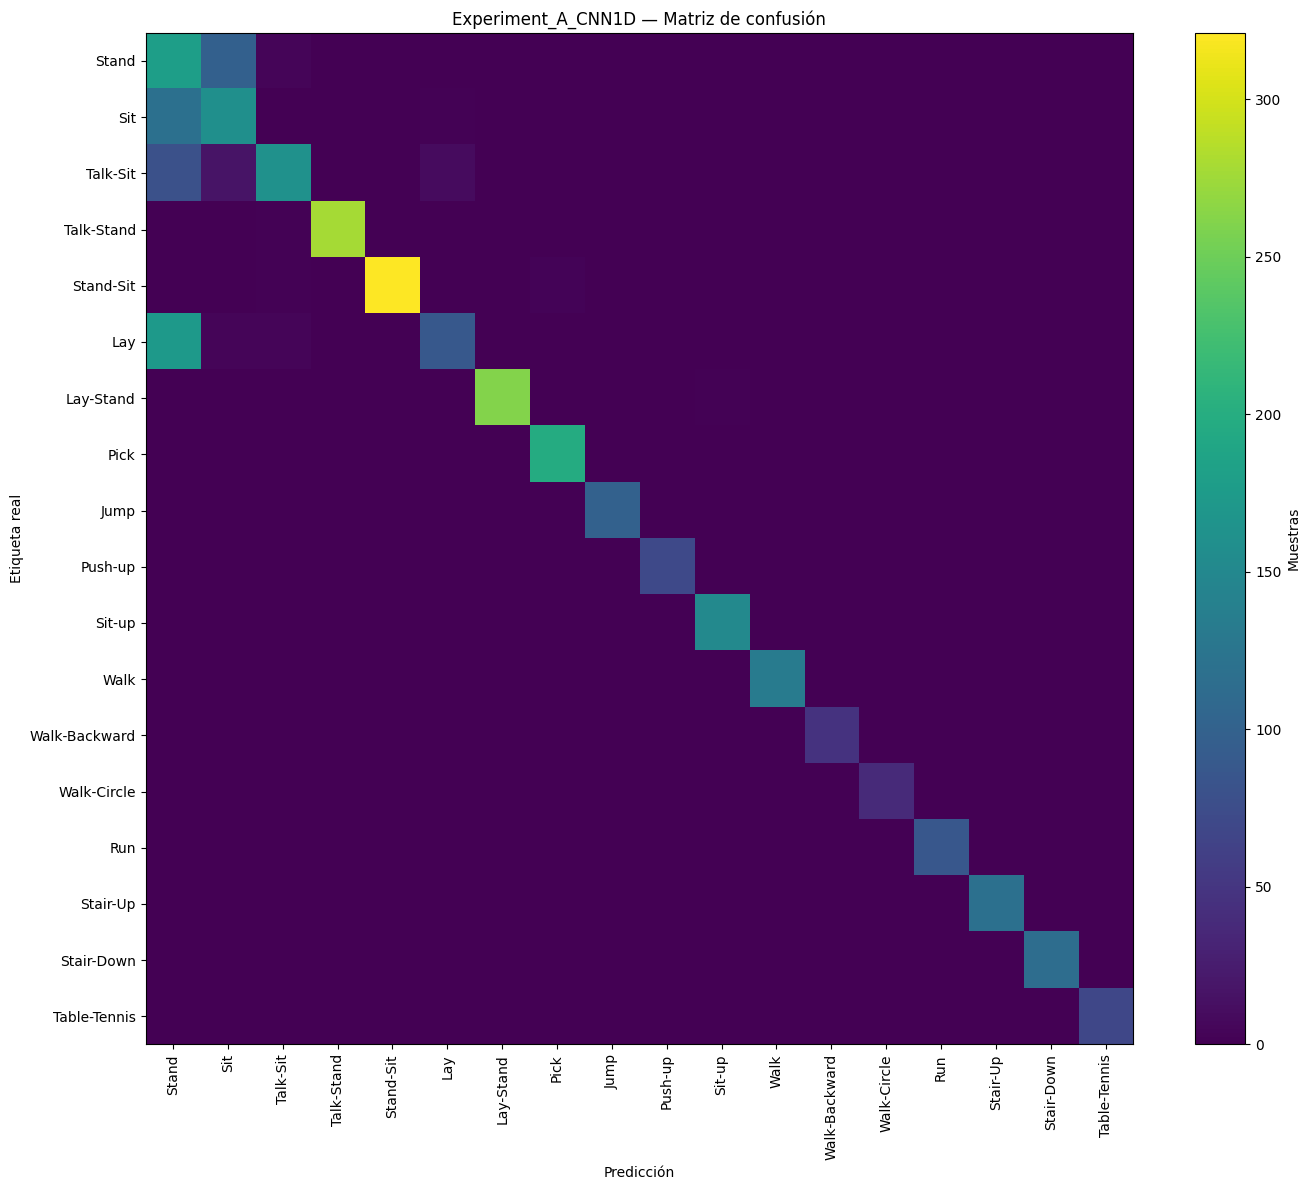

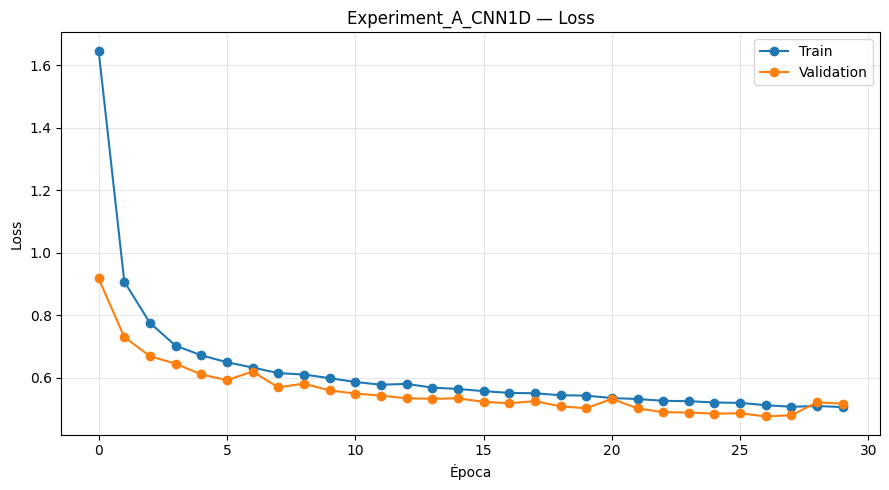

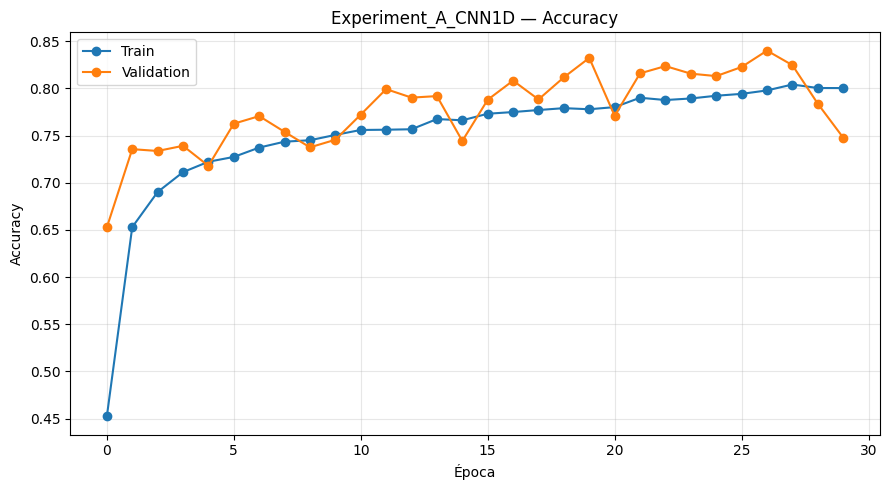

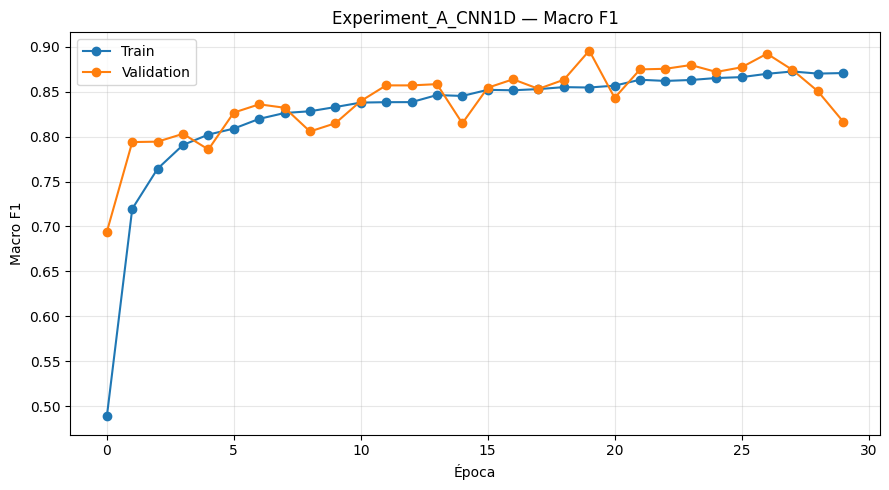

{
    "experiment": "Experiment_A_CNN1D",
    "configuration": {
        "experiment_name": "Experiment_A_CNN1D",
        "batch_size": 64,
        "max_epochs": 60,
        "patience": 10,
        "learning_rate": 0.0003,
        "weight_decay": 0.0001,
        "dropout": 0.25,
        "use_class_weights": true,
        "label_smoothing": 0.02
    },
    "trainable_parameters": 260754,
    "best_checkpoint": "/content/kuhar_results/Models/Experiment_A_CNN1D/checkpoints/epoch=19-valid_f1=0.8958-valid_loss=0.5025.ckpt",
    "training_seconds": 189.56955528259277,
    "test_accuracy": 0.8278188242852553,
    "balanced_accuracy": 0.8885865710707697,
    "macro_f1": 0.8929438957236387,
    "weighted_f1": 0.83382390502363
}


In [34]:
# 7.2 — CONFIGURACIÓN Y EJECUCIÓN DE LA CNN

RUN_CNN = True

CNN_CONFIG = {
    "experiment_name": "Experiment_A_CNN1D",
    "batch_size": 64,
    "max_epochs": 60,
    "patience": 10,
    "learning_rate": 3e-4,
    "weight_decay": 1e-4,
    "dropout": 0.25,
    "use_class_weights": True,
    "label_smoothing": 0.02
}

if RUN_CNN:
    cnn_datamodule = HARDataModule(
        X_train, y_train, X_valid, y_valid, X_test, y_test,
        batch_size=CNN_CONFIG["batch_size"],
        num_workers=NUM_WORKERS
    )
    cnn_datamodule.setup()

    cnn_network = CNN1D(
        num_channels=NUM_CHANNELS,
        num_classes=NUM_CLASSES,
        dropout=CNN_CONFIG["dropout"]
    )

    cnn_module = HARLightningModule(
        network=cnn_network,
        num_classes=NUM_CLASSES,
        learning_rate=CNN_CONFIG["learning_rate"],
        weight_decay=CNN_CONFIG["weight_decay"],
        class_weights=class_weights if CNN_CONFIG["use_class_weights"] else None,
        label_smoothing=CNN_CONFIG["label_smoothing"]
    )

    cnn_trainer, cnn_checkpoint, cnn_logger, cnn_directories = create_trainer(
        CNN_CONFIG["experiment_name"],
        CNN_CONFIG["max_epochs"],
        CNN_CONFIG["patience"]
    )

    start_time = time.time()
    cnn_trainer.fit(cnn_module, datamodule=cnn_datamodule)
    cnn_training_seconds = time.time() - start_time

    cnn_summary, cnn_test_results = save_evaluation(
        CNN_CONFIG["experiment_name"],
        cnn_module,
        cnn_datamodule,
        cnn_trainer,
        cnn_checkpoint,
        cnn_logger,
        cnn_directories,
        cnn_training_seconds,
        CNN_CONFIG
    )

    print(json.dumps(cnn_summary, indent=4))
else:
    print("CNN desactivada. Cambia RUN_CNN=True para ejecutarla.")

## 8. Experimento B — BiLSTM

In [35]:
# 8.1 — ARQUITECTURA BILSTM

class BiLSTM(nn.Module):
    def __init__(
        self,
        input_size=6,
        hidden_size=128,
        num_layers=2,
        num_classes=18,
        dropout=0.30
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_size * 2),
            nn.Dropout(dropout),
            nn.Linear(hidden_size * 2, 128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)
        sequence_output, _ = self.lstm(x)
        pooled = sequence_output.mean(dim=1)
        return self.classifier(pooled)

INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name           ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ network        │ BiLSTM             │  570 K │ train │     0 │
│ 1 │ loss_function  │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ train_accuracy │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ train_f1       │ MulticlassF1Score  │      0 │ train │     0 │
│ 4 │ valid_accuracy │ MulticlassAccuracy │      0 │ train │     0 │
│ 5 │ valid_f1       │ MulticlassF1Score  │      0 │ train │     0 │
│ 6 │ test_accuracy  │ MulticlassAccuracy │      0 │ train │     0 │
│ 7 │ test_f1        │ MulticlassF1Score  │      0 │ train │     0 │
└───┴────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 570 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 570 K                                                                                                
Total estimated model params size (MB): 2.281                                                                      
Modules in train mode: 16                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO: Restoring states from the checkpoint path at /content/kuhar_results/Models/Experiment_B_BiLSTM/checkpoints/epoch=52-valid_f1=0.9807-valid_loss=0.2793.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /content/kuhar_results/Models/Experiment_B_BiLSTM/checkpoints/epoch=52-valid_f1=0.9807-valid_loss=0.2793.ckpt
INFO: Loaded model weights from the checkpoint at /content/kuhar_results/Models/Experiment_B_BiLSTM/checkpoints/epoch=52-valid_f1=0.9807-valid_loss=0.2793.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at /content/kuhar_results/Models/Experiment_B_BiLSTM/checkpoints/epoch=52-valid_f1=0.9807-valid_loss=0.2793.ckpt


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9736588597297668     │
│          test_f1          │    0.9808118343353271     │
│         test_loss         │    0.27362990379333496    │
└───────────────────────────┴───────────────────────────┘

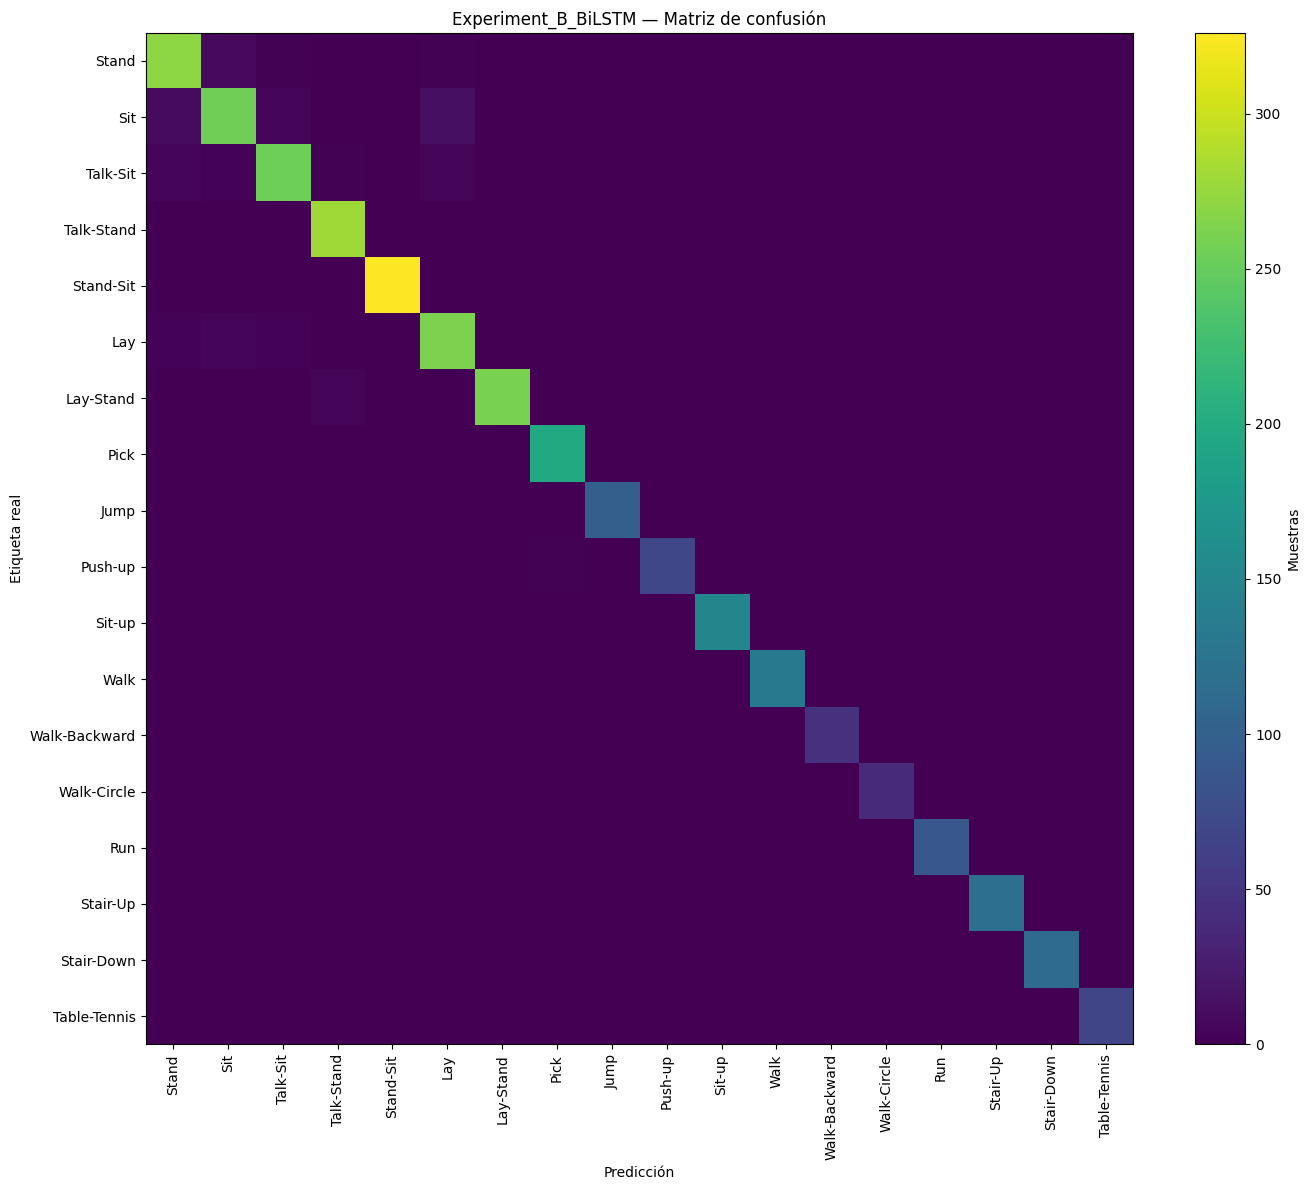

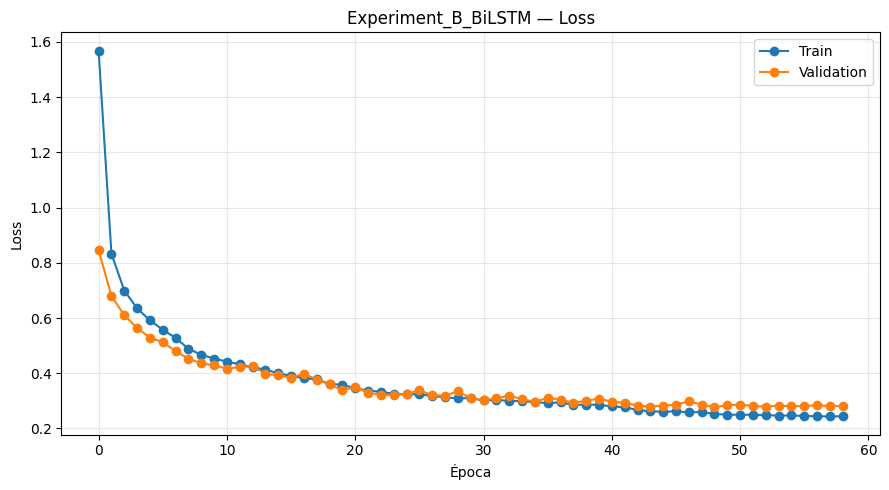

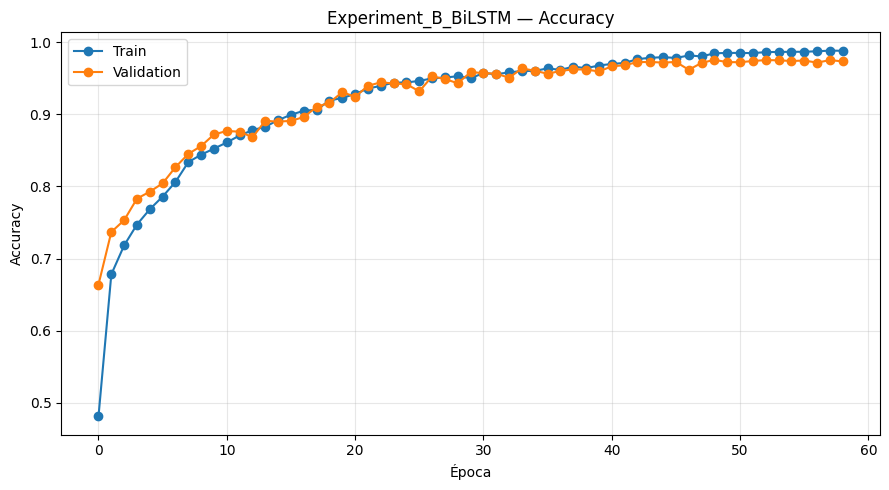

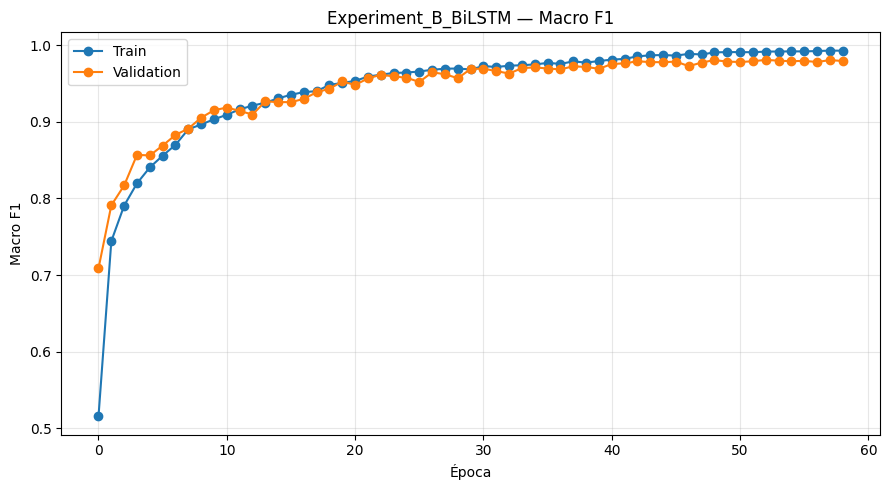

{
    "experiment": "Experiment_B_BiLSTM",
    "configuration": {
        "experiment_name": "Experiment_B_BiLSTM",
        "batch_size": 64,
        "max_epochs": 60,
        "patience": 10,
        "learning_rate": 0.0003,
        "weight_decay": 0.0001,
        "hidden_size": 128,
        "num_layers": 2,
        "dropout": 0.3,
        "use_class_weights": true,
        "label_smoothing": 0.02
    },
    "trainable_parameters": 570258,
    "best_checkpoint": "/content/kuhar_results/Models/Experiment_B_BiLSTM/checkpoints/epoch=52-valid_f1=0.9807-valid_loss=0.2793.ckpt",
    "training_seconds": 6396.042751550674,
    "test_accuracy": 0.9736588499839384,
    "balanced_accuracy": 0.9806919652591317,
    "macro_f1": 0.9808117676482906,
    "weighted_f1": 0.973629256476996
}


In [37]:
# 8.2 — CONFIGURACIÓN Y EJECUCIÓN DE LA BILSTM

RUN_BILSTM = True

BILSTM_CONFIG = {
    "experiment_name": "Experiment_B_BiLSTM",
    "batch_size": 64,
    "max_epochs": 60,
    "patience": 10,
    "learning_rate": 3e-4,
    "weight_decay": 1e-4,
    "hidden_size": 128,
    "num_layers": 2,
    "dropout": 0.30,
    "use_class_weights": True,
    "label_smoothing": 0.02
}

if RUN_BILSTM:
    bilstm_datamodule = HARDataModule(
        X_train, y_train, X_valid, y_valid, X_test, y_test,
        batch_size=BILSTM_CONFIG["batch_size"],
        num_workers=NUM_WORKERS
    )
    bilstm_datamodule.setup()

    bilstm_network = BiLSTM(
        input_size=NUM_CHANNELS,
        hidden_size=BILSTM_CONFIG["hidden_size"],
        num_layers=BILSTM_CONFIG["num_layers"],
        num_classes=NUM_CLASSES,
        dropout=BILSTM_CONFIG["dropout"]
    )

    bilstm_module = HARLightningModule(
        network=bilstm_network,
        num_classes=NUM_CLASSES,
        learning_rate=BILSTM_CONFIG["learning_rate"],
        weight_decay=BILSTM_CONFIG["weight_decay"],
        class_weights=class_weights if BILSTM_CONFIG["use_class_weights"] else None,
        label_smoothing=BILSTM_CONFIG["label_smoothing"]
    )

    bilstm_trainer, bilstm_checkpoint, bilstm_logger, bilstm_directories = create_trainer(
        BILSTM_CONFIG["experiment_name"],
        BILSTM_CONFIG["max_epochs"],
        BILSTM_CONFIG["patience"]
    )

    start_time = time.time()
    bilstm_trainer.fit(bilstm_module, datamodule=bilstm_datamodule)
    bilstm_training_seconds = time.time() - start_time

    bilstm_summary, bilstm_test_results = save_evaluation(
        BILSTM_CONFIG["experiment_name"],
        bilstm_module,
        bilstm_datamodule,
        bilstm_trainer,
        bilstm_checkpoint,
        bilstm_logger,
        bilstm_directories,
        bilstm_training_seconds,
        BILSTM_CONFIG
    )

    print(json.dumps(bilstm_summary, indent=4))
else:
    print("BiLSTM desactivada. Cambia RUN_BILSTM=True para ejecutarla.")

## 9. Experimento C — CRNN (CNN + BiLSTM)

In [38]:
# 9.1 — ARQUITECTURA CRNN

class CRNN(nn.Module):
    def __init__(
        self,
        num_channels=6,
        cnn_channels=128,
        hidden_size=128,
        num_layers=1,
        num_classes=18,
        dropout=0.30
    ):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv1d(num_channels, 64, kernel_size=9, padding=4, bias=False),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, cnn_channels, kernel_size=7, padding=3, bias=False),
            nn.BatchNorm1d(cnn_channels),
            nn.GELU(),
            nn.MaxPool1d(2)
        )

        self.lstm = nn.LSTM(
            input_size=cnn_channels,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_size * 2),
            nn.Dropout(dropout),
            nn.Linear(hidden_size * 2, 128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.cnn(x)
        x = x.permute(0, 2, 1)
        sequence_output, _ = self.lstm(x)
        pooled = sequence_output.mean(dim=1)
        return self.classifier(pooled)

INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name           ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ network        │ CRNN               │  361 K │ train │     0 │
│ 1 │ loss_function  │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ train_accuracy │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ train_f1       │ MulticlassF1Score  │      0 │ train │     0 │
│ 4 │ valid_accuracy │ MulticlassAccuracy │      0 │ train │     0 │
│ 5 │ valid_f1       │ MulticlassF1Score  │      0 │ train │     0 │
│ 6 │ test_accuracy  │ MulticlassAccuracy │      0 │ train │     0 │
│ 7 │ test_f1        │ MulticlassF1Score  │      0 │ train │     0 │
└───┴────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 361 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 361 K                                                                                                
Total estimated model params size (MB): 1.444                                                                      
Modules in train mode: 25                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO: Restoring states from the checkpoint path at /content/kuhar_results/Models/Experiment_C_CRNN/checkpoints/epoch=18-valid_f1=0.9108-valid_loss=0.4399.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /content/kuhar_results/Models/Experiment_C_CRNN/checkpoints/epoch=18-valid_f1=0.9108-valid_loss=0.4399.ckpt
INFO: Loaded model weights from the checkpoint at /content/kuhar_results/Models/Experiment_C_CRNN/checkpoints/epoch=18-valid_f1=0.9108-valid_loss=0.4399.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at /content/kuhar_results/Models/Experiment_C_CRNN/checkpoints/epoch=18-valid_f1=0.9108-valid_loss=0.4399.ckpt


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.8592997193336487     │
│          test_f1          │    0.9099627733230591     │
│         test_loss         │    0.4401891827583313     │
└───────────────────────────┴───────────────────────────┘

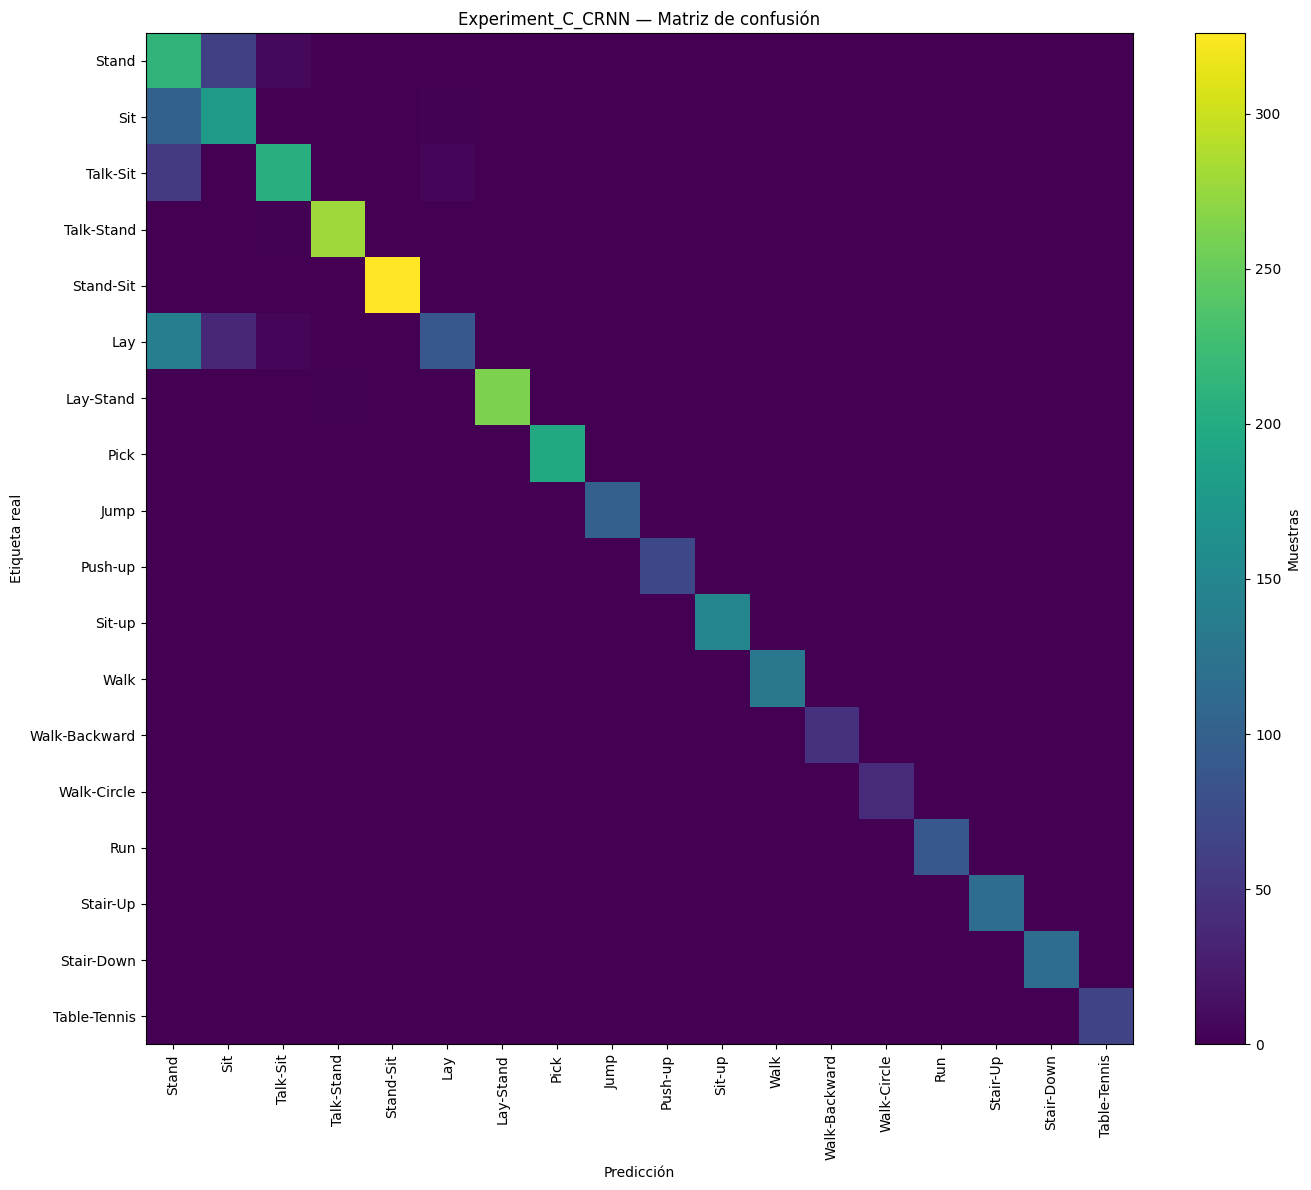

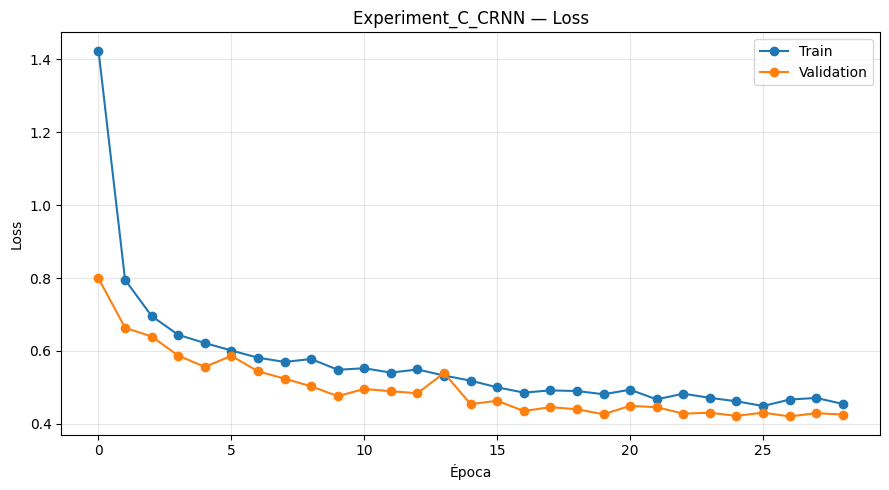

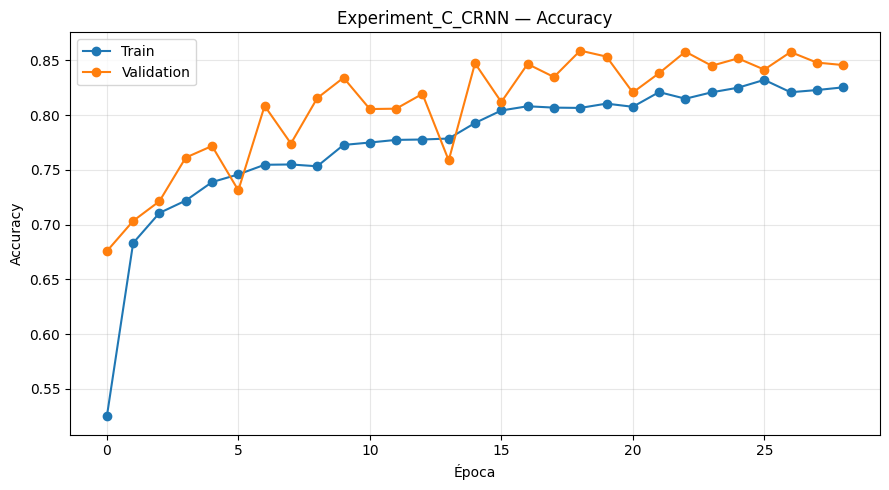

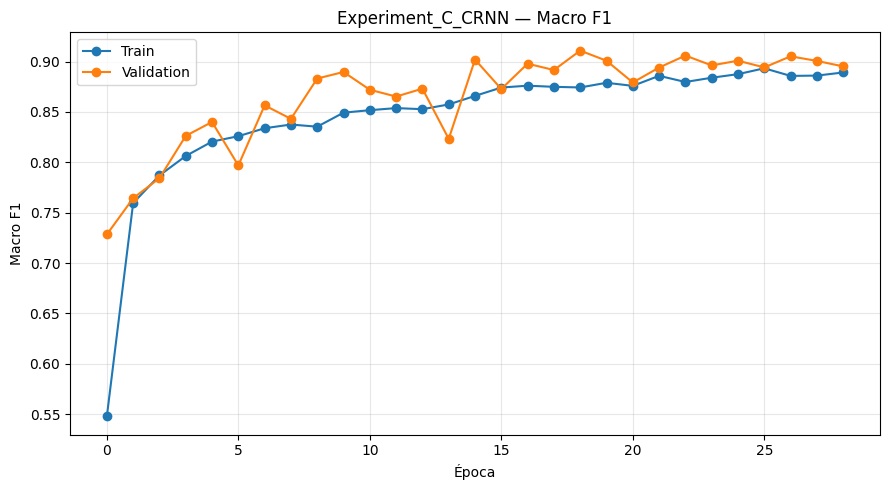

{
    "experiment": "Experiment_C_CRNN",
    "configuration": {
        "experiment_name": "Experiment_C_CRNN",
        "batch_size": 64,
        "max_epochs": 60,
        "patience": 10,
        "learning_rate": 0.0003,
        "weight_decay": 0.0001,
        "cnn_channels": 128,
        "hidden_size": 128,
        "num_layers": 1,
        "dropout": 0.3,
        "use_class_weights": true,
        "label_smoothing": 0.02
    },
    "trainable_parameters": 361106,
    "best_checkpoint": "/content/kuhar_results/Models/Experiment_C_CRNN/checkpoints/epoch=18-valid_f1=0.9108-valid_loss=0.4399.ckpt",
    "training_seconds": 442.49564695358276,
    "test_accuracy": 0.8592997108898169,
    "balanced_accuracy": 0.9075904499796845,
    "macro_f1": 0.9099627563067069,
    "weighted_f1": 0.8602579997809447
}


In [39]:
# 9.2 — CONFIGURACIÓN Y EJECUCIÓN DE LA CRNN

RUN_CRNN = True

CRNN_CONFIG = {
    "experiment_name": "Experiment_C_CRNN",
    "batch_size": 64,
    "max_epochs": 60,
    "patience": 10,
    "learning_rate": 3e-4,
    "weight_decay": 1e-4,
    "cnn_channels": 128,
    "hidden_size": 128,
    "num_layers": 1,
    "dropout": 0.30,
    "use_class_weights": True,
    "label_smoothing": 0.02
}

if RUN_CRNN:
    crnn_datamodule = HARDataModule(
        X_train, y_train, X_valid, y_valid, X_test, y_test,
        batch_size=CRNN_CONFIG["batch_size"],
        num_workers=NUM_WORKERS
    )
    crnn_datamodule.setup()

    crnn_network = CRNN(
        num_channels=NUM_CHANNELS,
        cnn_channels=CRNN_CONFIG["cnn_channels"],
        hidden_size=CRNN_CONFIG["hidden_size"],
        num_layers=CRNN_CONFIG["num_layers"],
        num_classes=NUM_CLASSES,
        dropout=CRNN_CONFIG["dropout"]
    )

    crnn_module = HARLightningModule(
        network=crnn_network,
        num_classes=NUM_CLASSES,
        learning_rate=CRNN_CONFIG["learning_rate"],
        weight_decay=CRNN_CONFIG["weight_decay"],
        class_weights=class_weights if CRNN_CONFIG["use_class_weights"] else None,
        label_smoothing=CRNN_CONFIG["label_smoothing"]
    )

    crnn_trainer, crnn_checkpoint, crnn_logger, crnn_directories = create_trainer(
        CRNN_CONFIG["experiment_name"],
        CRNN_CONFIG["max_epochs"],
        CRNN_CONFIG["patience"]
    )

    start_time = time.time()
    crnn_trainer.fit(crnn_module, datamodule=crnn_datamodule)
    crnn_training_seconds = time.time() - start_time

    crnn_summary, crnn_test_results = save_evaluation(
        CRNN_CONFIG["experiment_name"],
        crnn_module,
        crnn_datamodule,
        crnn_trainer,
        crnn_checkpoint,
        crnn_logger,
        crnn_directories,
        crnn_training_seconds,
        CRNN_CONFIG
    )

    print(json.dumps(crnn_summary, indent=4))
else:
    print("CRNN desactivada. Cambia RUN_CRNN=True para ejecutarla.")

## 10. Comparación y exportación

In [40]:
# 10.2 — COMPRESIÓN DE TODOS LOS RESULTADOS

archive_path = shutil.make_archive(
    base_name=str(PROJECT_ROOT / "kuhar_results"),
    format="zip",
    root_dir=str(RESULTS_ROOT)
)

print("Archivo ZIP creado:")
print(archive_path)

Archivo ZIP creado:
/content/kuhar_results.zip


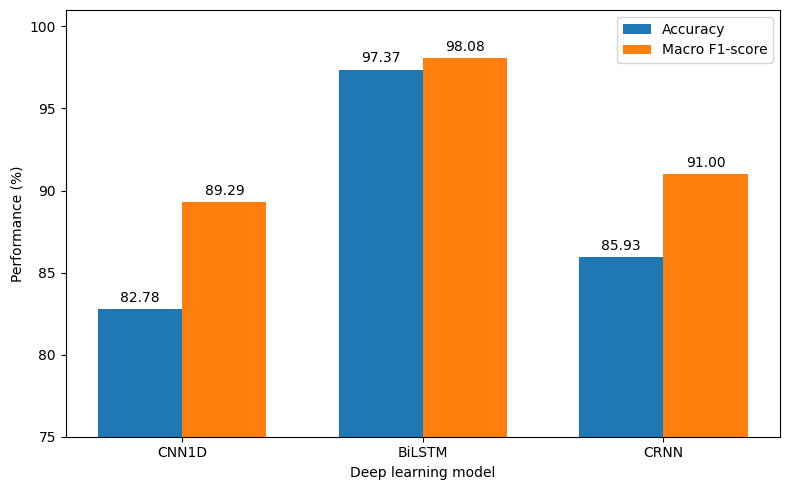

In [41]:
import numpy as np
import matplotlib.pyplot as plt

models = ["CNN1D", "BiLSTM", "CRNN"]
accuracy = [82.78, 97.37, 85.93]
macro_f1 = [89.29, 98.08, 91.00]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

bars1 = ax.bar(
    x - width / 2,
    accuracy,
    width,
    label="Accuracy"
)

bars2 = ax.bar(
    x + width / 2,
    macro_f1,
    width,
    label="Macro F1-score"
)

ax.set_ylabel("Performance (%)")
ax.set_xlabel("Deep learning model")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(75, 101)
ax.legend()

ax.bar_label(bars1, fmt="%.2f", padding=3)
ax.bar_label(bars2, fmt="%.2f", padding=3)

plt.tight_layout()

plt.savefig(
    "model_performance_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

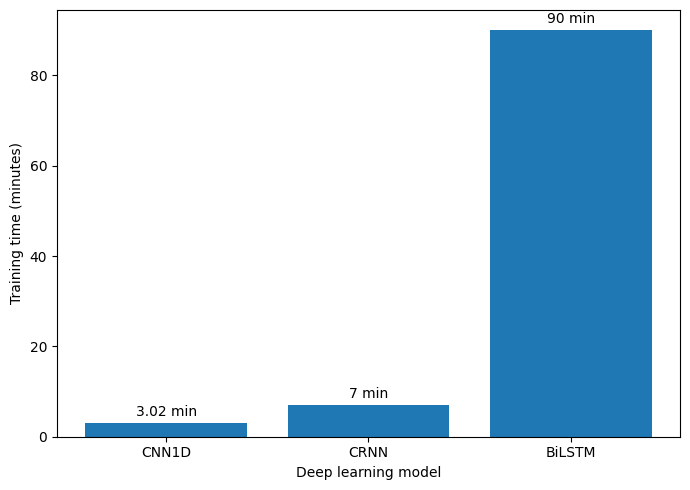

In [42]:
import matplotlib.pyplot as plt

models = ["CNN1D", "CRNN", "BiLSTM"]

training_time_minutes = [
    181 / 60,   # CNN1D
    7,          # CRNN
    90          # BiLSTM
]

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    models,
    training_time_minutes
)

ax.set_xlabel("Deep learning model")
ax.set_ylabel("Training time (minutes)")

ax.bar_label(
    bars,
    labels=[
        "3.02 min",
        "7 min",
        "90 min"
    ],
    padding=3
)

plt.tight_layout()

plt.savefig(
    "training_time_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()